# Time evolution I — TEBD: Trotter–Suzuki evolution of a state vector

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 5 — Ground states and unitary dynamics*

## 1. Introduction and motivation

**The physical question.** Prepare a chain of interacting spins in a simple state — all spins up, a Néel pattern $\uparrow\downarrow\uparrow\downarrow$, a domain wall $\uparrow\uparrow\uparrow\downarrow\downarrow\downarrow$ — and let it go.
The questions are how fast the magnetisation spreads, whether the system "forgets" its initial state, and how quickly entanglement grows. Such *quench experiments* are routinely performed today with ultracold atoms in optical lattices,
trapped ions, Rydberg-atom arrays and superconducting qubits, and they are a central probe of the dynamics of quantum matter. The theory is "just" the Schrödinger equation (we set $\hbar=1$),

$$ i\,\frac{d}{dt}|\psi(t)\rangle=H|\psi(t)\rangle\qquad\Longrightarrow\qquad|\psi(t)\rangle=e^{-iHt}|\psi(0)\rangle , $$

but for $N$ spins $e^{-iHt}$ is a $2^N\times2^N$ matrix. In [notebook 04 (Chapter 2)](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb) we computed it by full diagonalisation — $O(8^N)$ operations, $O(4^N)$ memory, hopeless beyond $N\approx12$–$14$.

**The idea of this notebook.** The Hamiltonians of interest are sums of *local* terms, $H=\sum_kh_k$, each acting on one or two spins. The exponential of a single term, $e^{-ih_k\,dt}$, is a tiny $4\times4$ (or $2\times2$) unitary that we can compute exactly
and apply to the state tensor with one einsum at cost $O(2^N)$ ([notebook 05, Chapter 3](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb)). If the terms commuted, $e^{-iH\,dt}$ would simply be the product of these small unitaries. They do not commute — but for a **short** time step
the product is a good approximation, with an error we can *derive*, *measure* and *systematically reduce*:

$$ e^{-iH\,dt}\;\approx\;\prod_k e^{-ih_k\,dt}\qquad\text{(Trotter 1959, Suzuki 1976)}. $$

**A word on the name.** In the literature **TEBD — time-evolving block decimation** (Vidal 2003, 2004) denotes one specific algorithm: this sequence of two-site gates applied to a *matrix product state*, each gate followed by a singular-value truncation that keeps the bond dimension bounded — the "decimation" of the name (Schollwöck 2011, Section 7, compares it with the other MPS time-evolution schemes).
What we do here is the same gate sequence applied to the **full state vector**, stored as a rank-$N$ tensor: no matrix product state, no truncation. Strictly, that is Trotterised state-vector evolution; calling it TEBD, as is common, names the gate layout rather than the data structure.
The distinction matters because it decides what limits the simulation: here memory ($2^N$ amplitudes) and **the Trotter error as the only source of error**, there the bond dimension and the truncation error on top of the Trotter error. The MPS version is the subject of [notebook 18 (Chapter 7)](../ch07_tensor_networks/18_mps_tebd.ipynb);
everything derived below about Trotter errors carries over to it unchanged, which is why this is the place to understand them thoroughly.
The same product formula is also the basic algorithm of *digital quantum simulation* (Lloyd 1996): every gate below could be executed on a quantum computer, so what we learn about Trotter errors applies there verbatim.

**Road map.**

1. One bond: the exact two-site gate $e^{-ih\,dt}$, its closed form for the Heisenberg coupling, and how it acts on the state tensor (Section 3).
2. Many bonds: why $e^{A+B}\neq e^Ae^B$, the Baker–Campbell–Hausdorff formula, the **first-order** Trotter step, the even/odd ("brick-wall") layout, local vs global error (Section 4).
3. The **second-order** (Strang) and **fourth-order** (Suzuki, Forest–Ruth/Yoshida) formulas, derived from a symmetry argument (Section 5).
4. Implementation with `jit` and `lax.scan`, validation against exact evolution (Section 6).
5. **Measured error scaling**: local error $\propto dt^{p+1}$, global error $\propto dt^{p}$, accumulation in time, prefactors predicted by commutators (Section 7).
6. **Conserved quantities as diagnostics**: what the norm, the magnetisation and the energy can and cannot tell you; commuting special cases with zero Trotter error (Sections 8–9).
7. **Cost**: gates per step, gate fusion, compile vs run time, work–precision diagram and the choice of the order (Section 10)
8. A convergence test that needs no exact reference, and a domain-wall quench of $N=18$ spins checked against free fermions (Section 11).

### What you will learn

**Physics**

* What a quantum quench is and what is measured in it; melting of a domain wall in the XX and Heisenberg chains; ballistic spreading with a maximal velocity.
* Why Trotterised dynamics conserves a slightly *modified* energy, and exactly conserves every symmetry shared by all gates.

**Numerical methods**

* Operator splitting: Lie–Trotter, Strang, Suzuki's fractal construction and the Forest–Ruth/Yoshida triple jump; order conditions.
* Local vs global error, error accumulation $\epsilon\lesssim t\,dt^{p}$, commutator prefactors and the commutator bound on the Trotter error, its dependence on the system size, effective (shadow) Hamiltonians.
* Practical convergence control by step halving (Richardson-type error estimate); work–precision diagrams; unconditional stability, and how to choose $dt$ when nothing ever blows up.

**Implementation practice**

* A time step as a list of `(qubits, 4x4 unitary)` gates applied by einsum; gate lists as data that can be reordered and fused.
* `jax.jit` + `lax.scan` for time loops with observables, `lax.fori_loop` for a traced number of steps; tracing `dt` so that one compilation serves all step sizes.
* Timing (compile vs run), counting gates as a hardware-independent cost measure.

### Prerequisites
* [Notebook 04 (Chapter 2) — Time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb): exact propagators, a first look at Trotterisation with dense matrices, and the step-size rule of explicit RK4.
* [Notebook 05 (Chapter 3) — Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): `apply_gate`, Hamiltonians as lists of local terms.
* [Notebook 11 (Chapter 5) — Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb): the models (TFIM, XXZ) and their symmetries.
* [Notebook 01 (Chapter 1) — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `lax.scan`.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The engine functions used in this notebook

The folded cell below contains the simulator primitives we use, verbatim from the course engine. The ones that matter here:

| function | what it does |
|---|---|
| `apply_gate(psi, U, qubits)` | contracts a $2^k\times2^k$ matrix with $k$ axes of the state tensor (einsum), cost $O(2^k2^N)$ |
| `heisenberg_terms(N, Jxx, Jyy, Jzz, hx, hy, hz)` | the Hamiltonian as a list `[(qubits, small matrix), ...]` |
| `apply_hamiltonian`, `energy` | $H\lvert\psi\rangle$ and $\langle\psi\rvert H\lvert\psi\rangle$, matrix-free |
| `tebd_gates(terms, dt, order)` | gate list of **one** Trotter–Suzuki step of order 1, 2 or 4 — *derived in Sections 4–5* |
| `apply_gates(psi, gates)` | applies a gate list in order |
| `tebd_evolve(psi, terms, dt, n_steps, order, observe)` | the time loop as a `lax.scan`, recording observables |
| `exact_evolve(psi, terms, t)` | dense reference $Ve^{-iEt}V^\dagger\lvert\psi\rangle$ — **validation only**, small $N$ |

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
SWAP = jnp.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def tebd_evolve(psi, terms, dt, n_steps, order=2, observe=None):
    """Evolve for n_steps*dt with TEBD and record `observe(psi)` after every step.

    JAX    `lax.scan(step, carry, xs, length)` compiles the step ONCE and loops inside XLA
           (a Python for-loop under jit would unroll n_steps copies of the graph).
           Returns (final_state, stacked_observables).
    """
    gates = tebd_gates(terms, dt, order)

    def step(psi, _):
        psi = apply_gates(psi, gates)
        return psi, (observe(psi) if observe is not None else 0.0)

    return lax.scan(step, psi, None, length=n_steps)

def exact_evolve(psi, terms, t):
    """Dense reference for small N: full diagonalisation H = V w V^dag, |psi(t)> = V e^{-i w t} V^dag |psi>.
    O(8^N) time, O(4^N) memory -- the wall that matrix-free methods avoid; used only to validate them."""
    N = psi.ndim
    w, v = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    return ((v * jnp.exp(-1j * t * w)) @ (v.conj().T @ psi.reshape(-1))).reshape((2,) * N)


In [3]:
# ==============================================================================
# PLOT STYLE: colour-blind-friendly palette (Okabe-Ito) used in all figures below
# ==============================================================================
CB = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=CB), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 100, "font.size": 10})

## 3. One bond: the exact two-site gate

### 3.1 Exponential of a small Hermitian matrix

Take a single bond term, e.g. the XXZ coupling $h=J(X\!\otimes\!X+Y\!\otimes\!Y+\Delta\,Z\!\otimes\!Z)$, a Hermitian $4\times4$ matrix. Diagonalise it, $h=V\,\mathrm{diag}(w)\,V^\dagger$; then every function of $h$ is obtained by applying the function to the eigenvalues,

$$ e^{-ih\tau}=V\,\mathrm{diag}\big(e^{-iw_1\tau},\dots,e^{-iw_4\tau}\big)\,V^\dagger . $$

(Insert the power series of the exponential and use $h^n=Vw^nV^\dagger$.) This is what the engine helper `_expm_herm(h, tau)` does: it is *exact* to machine precision for any $\tau$, costs nothing (a $4\times4$ `eigh`), and is traceable by JAX, so `tau` may be a traced value.

### 3.2 A closed form for the Heisenberg bond

For the isotropic coupling there is a formula worth knowing. The SWAP operator, $\mathrm{SWAP}|ab\rangle=|ba\rangle$, can be written as $\mathrm{SWAP}=\tfrac12(\mathbb 1+X\!\otimes\!X+Y\!\otimes\!Y+Z\!\otimes\!Z)$ (check it on the four basis states), hence

$$ h_{\rm Heis}=J\,(XX+YY+ZZ)=J\,(2\,\mathrm{SWAP}-\mathbb 1). $$

Since $\mathrm{SWAP}^2=\mathbb 1$, the exponential series splits into even and odd powers exactly as for a single Pauli matrix, $e^{-i\theta\,\mathrm{SWAP}}=\cos\theta\,\mathbb 1-i\sin\theta\,\mathrm{SWAP}$, and therefore

$$ e^{-ih_{\rm Heis}\tau}=e^{iJ\tau}\big[\cos(2J\tau)\,\mathbb 1-i\sin(2J\tau)\,\mathrm{SWAP}\big]. \qquad (1)$$

> **Physics insight.** The Heisenberg interaction *is* a partial swap: at $2J\tau=\pi/2$ the two spins have exchanged their states completely. This "$\sqrt{\text{SWAP}}$-type" gate is the native two-qubit gate of exchange-coupled spin qubits in quantum dots.

### 3.3 How the gate acts on the state tensor

A reminder from [notebook 05 (Chapter 3)](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb). The state of $N$ spins is a tensor $\psi[s_0,\dots,s_{N-1}]$ of shape $(2,)^N$. A two-site gate $U$ (a $4\times4$ matrix, reshaped to $U[a',b';a,b]$ with shape $(2,2,2,2)$) on sites $(1,2)$ of an $N=4$ chain acts as

$$ \psi'[s_0,a',b',s_3]=\sum_{a,b}U[a',b';a,b]\;\psi[s_0,a,b,s_3]\qquad\Longleftrightarrow\qquad\texttt{einsum("ABab,sabt->sABt", U4, psi)} . $$

The $2^N\times2^N$ matrix $\mathbb 1\otimes U\otimes\mathbb 1$ is never formed; the cost is $4\cdot2^N$ multiplications per gate. `apply_gate` builds the einsum string for any $N$ and any pair of sites.

In [4]:
# ==============================================================================
# CHECKPOINT 1: the two-site gate -- eigendecomposition vs closed form (1), unitarity, action on a state
# ==============================================================================
def expm_hermitian(h, tau):
    """exp(-i tau h) for a small Hermitian matrix h.

    MATH   h = V diag(w) V^dag   =>   exp(-i tau h) = V diag(exp(-i tau w)) V^dag     (exact for any tau)
    JAX    eigh and exp are traceable: tau may be a traced scalar (we will jit over dt later).
    (Identical to the engine's private helper `_expm_herm`, repeated here because we derive it.)
    """
    w, V = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (V * jnp.exp(-1j * tau * w)) @ V.conj().T          # (V * d) multiplies column k of V by d_k


J_test, tau_test = 0.7, 0.3
h_heis = J_test * (XX + YY + ZZ)
U_eig = expm_hermitian(h_heis, tau_test)
U_closed = jnp.exp(1j * J_test * tau_test) * (jnp.cos(2 * J_test * tau_test) * jnp.eye(4) - 1j * jnp.sin(2 * J_test * tau_test) * SWAP)
print(f"SWAP = (1 + XX + YY + ZZ)/2           : {float(jnp.max(jnp.abs(SWAP - 0.5 * (jnp.eye(4) + XX + YY + ZZ)))):.1e}")
print(f"eigendecomposition vs closed form (1) : {float(jnp.max(jnp.abs(U_eig - U_closed))):.1e}")
print(f"unitarity  max|U^dag U - 1|           : {float(jnp.max(jnp.abs(U_eig.conj().T @ U_eig - jnp.eye(4)))):.1e}")
assert float(jnp.max(jnp.abs(U_eig - U_closed))) < TOL

# action on a state: for a SINGLE bond the gate is the exact evolution -- compare with the dense reference (N=4)
psi_test = haar_state(jax.random.PRNGKey(0), 4)
one_bond = [((1, 2), h_heis)]
err_one = jnp.linalg.norm(apply_gate(psi_test, U_eig, (1, 2)) - exact_evolve(psi_test, one_bond, tau_test))
print(f"one bond, N=4: einsum gate vs dense exp(-iHt): {float(err_one):.1e}")
assert float(err_one) < TOL

SWAP = (1 + XX + YY + ZZ)/2           : 0.0e+00
eigendecomposition vs closed form (1) : 1.9e-16
unitarity  max|U^dag U - 1|           : 3.3e-16


one bond, N=4: einsum gate vs dense exp(-iHt): 9.9e-17


The closed form (1), the eigendecomposition and the dense reference all agree to machine precision: **for a single term there is no approximation whatsoever**, whatever the value of $\tau$. All the difficulty comes from having *several* terms that do not commute.

## 4. Many bonds: non-commuting exponentials and the first-order Trotter step

### 4.1 Why $e^{A+B}\ne e^Ae^B$

For numbers $e^{a+b}=e^ae^b$. For operators, expand both sides to second order in a small parameter $\varepsilon$:

$$ e^{\varepsilon A}e^{\varepsilon B}=\Big(1+\varepsilon A+\tfrac{\varepsilon^2}{2}A^2\Big)\Big(1+\varepsilon B+\tfrac{\varepsilon^2}{2}B^2\Big)+O(\varepsilon^3)
   =1+\varepsilon(A+B)+\tfrac{\varepsilon^2}{2}\big(A^2+2AB+B^2\big)+O(\varepsilon^3), $$

$$ e^{\varepsilon(A+B)}=1+\varepsilon(A+B)+\tfrac{\varepsilon^2}{2}\big(A^2+AB+BA+B^2\big)+O(\varepsilon^3). $$

The two agree at first order and differ at second order by $\tfrac{\varepsilon^2}{2}(AB-BA)$:

$$ e^{\varepsilon A}e^{\varepsilon B}-e^{\varepsilon(A+B)}=\frac{\varepsilon^2}{2}[A,B]+O(\varepsilon^3). \qquad (2)$$

This is the lowest order of the **Baker–Campbell–Hausdorff (BCH) formula** $e^{\varepsilon A}e^{\varepsilon B}=\exp\!\big(\varepsilon(A+B)+\tfrac{\varepsilon^2}{2}[A,B]+\tfrac{\varepsilon^3}{12}([A,[A,B]]+[B,[B,A]])+\dots\big)$, in which *all* corrections are nested commutators.
If $[A,B]=0$ all of them vanish and the product formula is exact.

### 4.2 The first-order (Lie–Trotter) step

Substituting $\varepsilon A\to-iA\,dt$, $\varepsilon B\to-iB\,dt$ in Eq. (2), with $H=A+B$:

$$ S_1(dt)\equiv e^{-iA\,dt}e^{-iB\,dt}=e^{-iH\,dt}-\frac{dt^2}{2}[A,B]+O(dt^3). \qquad (3)$$

The error of **one step** — the *local error* — is $O(dt^2)$, with a prefactor set by the commutator. For a product of many terms, $S_1=e^{-ih_K dt}\cdots e^{-ih_1dt}$, the same expansion gives $-\tfrac{dt^2}{2}\sum_{j>k}[h_j,h_k]$.

**Ordering convention.** Operators act on the ket to their right, so in a product the factor applied *first* stands *rightmost*: in Eq. (3) it is $B$, and in the $K$-term product it is $h_1$. The gate lists of this notebook are written in the order in which the gates are applied,
so the first entry of a list is the rightmost factor of the corresponding product. Keeping this straight is the difference between $[A,B]$ and $[B,A]$ — a sign — in every error formula below.

### 4.3 From local to global error

To reach time $t$ we apply $n=t/dt$ steps. Write $U=e^{-iH\,dt}$ for the exact step and use the telescoping identity

$$ S^n-U^n=\sum_{k=0}^{n-1}S^{\,k}\,(S-U)\,U^{\,n-1-k}. $$

$S$ and $U$ are unitary, so they do not change norms, and the triangle inequality gives

$$ \big\|(S^n-U^n)|\psi\rangle\big\|\;\le\;n\,\|S-U\|\;=\;\frac{t}{dt}\,O(dt^{2})=O(t\,dt). \qquad (4)$$

**Errors add up at most linearly in time** (no exponential blow-up, thanks to unitarity), and one power of $dt$ is lost: a method with local error $O(dt^{p+1})$ has global error $O(t\,dt^{p})$ and is called a method **of order $p$**. Lie–Trotter is first order.

### 4.4 The even/odd (brick-wall) layout

For a chain with nearest-neighbour bonds, the terms on **even** bonds $(0,1),(2,3),\dots$ act on disjoint pairs of spins and therefore commute with each other; the same holds for the **odd** bonds $(1,2),(3,4),\dots$. With

$$ H=\underbrace{\sum_{\text{even bonds}}h_{j,j+1}}_{A}+\underbrace{\sum_{\text{odd bonds}}h_{j,j+1}}_{B} $$

each layer is an **exact** product of commuting two-site gates, $e^{-iA\,dt}=\prod_{\rm even}e^{-ih_{j,j+1}dt}$, and the only error is the one between the two layers, Eq. (3):

```
  site   0   1   2   3   4   5
         |   |   |   |   |   |
         [ U ]   [ U ]   [ U ]      layer A  (even bonds)  = exp(-i A dt)   exactly
         |   [ U ]   [ U ]   |      layer B  (odd bonds)   = exp(-i B dt)   exactly
         |   |   |   |   |   |                one first-order step S1(dt)
```

The even layer is applied first, so with the convention of Section 4.2 one step is $S_1(dt)=e^{-iB\,dt}e^{-iA\,dt}$ — Eq. (3) with the roles of $A$ and $B$ interchanged. Its leading local error is therefore

$$ S_1(dt)-e^{-iH\,dt}=-\frac{dt^2}{2}[B,A]+O(dt^3),\qquad A=\text{even bonds (applied first)},\ B=\text{odd bonds}. \qquad (3')$$

We check Eq. (3') numerically in a moment; reversing the two layers would flip the sign of the error vector without changing its norm, so a test of the norm alone cannot detect this mistake.

Single-site field terms $h_xX_i+\dots$ can be treated as a third layer, or — better — **absorbed into the bonds**: give every bond a share of the fields of its two sites, so that the sum over bonds is unchanged. Then $H$ is again a sum of two layers,
there are fewer gates to apply (a first instance of *gate fusion*), and the two-layer theory applies literally. Other orderings are equally legitimate first-order formulas — e.g. sweeping through the bonds from left to right, which is
what one gets by feeding the engine's `heisenberg_terms` list directly into `tebd_gates`. Since the bond terms of a chain do **not** all commute, reordering them produces a *different* unitary; what stays the same is the
order of accuracy, and what changes is the error prefactor. Section 7.1 measures the difference for the second-order scheme.

In [5]:
# ==============================================================================
# STEP 1: term lists for TEBD -- absorb fields into bonds, order the bonds as even/odd layers
# ==============================================================================
def absorb_fields_into_bonds(terms, N):
    """Rewrite H = sum_bonds h_ij + sum_i f_i  as a sum over bonds only (same operator, fewer terms).

    MATH   every site i that belongs to z_i bonds gives the share f_i / z_i to each of them:
               h'_ij = h_ij + (f_i / z_i) x 1 + 1 x (f_j / z_j)          =>   sum_bonds h'_ij = H   exactly.
    WHY    fewer gates per Trotter step (no separate single-site layer) and a clean two-layer even/odd splitting.
    """
    bonds = [(q, jnp.asarray(h, dtype=CDTYPE)) for q, h in terms if len(q) == 2]
    fields = {q[0]: jnp.asarray(f, dtype=CDTYPE) for q, f in terms if len(q) == 1}
    z = np.zeros(N, dtype=int)                                   # coordination number of every site
    for (i, j), _ in bonds:
        z[i] += 1; z[j] += 1
    out = []
    for (i, j), h in bonds:
        fi = fields.get(i, jnp.zeros((2, 2), CDTYPE)) / z[i]
        fj = fields.get(j, jnp.zeros((2, 2), CDTYPE)) / z[j]
        out.append(((i, j), h + jnp.kron(fi, I2) + jnp.kron(I2, fj)))   # first listed qubit = LEFT factor of kron
    return out


def even_odd_order(bond_terms):
    """Reorder nearest-neighbour bond terms of a chain: all even bonds (0,1),(2,3),.. first, then all odd bonds."""
    even = [t for t in bond_terms if min(t[0]) % 2 == 0]
    odd = [t for t in bond_terms if min(t[0]) % 2 == 1]
    return even + odd


def layers(bond_terms):
    """Split an even/odd-ordered bond list into the two layers (A = even bonds, B = odd bonds)."""
    return ([t for t in bond_terms if min(t[0]) % 2 == 0], [t for t in bond_terms if min(t[0]) % 2 == 1])


# ------------------------------------------------------------------------------
# PARAMETERS of the running example: XXZ chain in a tilted field (generic, non-integrable, nothing commutes)
# ------------------------------------------------------------------------------
N = 10
J, Delta, hx, hz = 1.0, 0.5, 0.3, 0.2
terms_sweep = heisenberg_terms(N, Jxx=J, Jyy=J, Jzz=J * Delta, hx=hx, hz=hz)     # engine order: bonds left->right, then fields
terms_eo = even_odd_order(absorb_fields_into_bonds(terms_sweep, N))              # fields absorbed, even bonds then odd bonds
psi0 = product_state("01" * (N // 2))                                           # Neel state |0101...>

print(f"'sweep' list   : {len(terms_sweep)} terms  ({N - 1} bonds + {N} fields)")
print(f"'even/odd' list: {len(terms_eo)} terms, bond order = {[q for q, _ in terms_eo]}")
H_a, H_b = dense_hamiltonian(terms_sweep, N), dense_hamiltonian(terms_eo, N)     # validation only (1024 x 1024)
print(f"CHECKPOINT  same Hamiltonian?  max|H_sweep - H_even/odd| = {float(jnp.max(jnp.abs(H_a - H_b))):.1e}")
assert float(jnp.max(jnp.abs(H_a - H_b))) < TOL

'sweep' list   : 19 terms  (9 bonds + 10 fields)
'even/odd' list: 9 terms, bond order = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (1, 2), (3, 4), (5, 6), (7, 8)]


CHECKPOINT  same Hamiltonian?  max|H_sweep - H_even/odd| = 1.8e-15


Both lists describe the same operator (checked densely on $N=10$), with 19 and 9 terms respectively. The engine's `tebd_gates(terms, dt, order=1)` turns a term list into the gate list $[(q_k,e^{-ih_kdt})]$, applied in list order.

### 4.5 Checkpoint: the first-order step and its predicted error

Beyond the order $O(dt^2)$, Eq. (3') predicts the *vector* of the leading local error, $\big(S_1(dt)-e^{-iH\,dt}\big)|\psi\rangle\approx-\tfrac{dt^2}{2}[B,A]|\psi\rangle$. We can compute $[B,A]|\psi\rangle=B(A|\psi\rangle)-A(B|\psi\rangle)$
matrix-free with `apply_hamiltonian` on the two sub-lists and compare — both the norm and the *direction*. The direction is tested by the projection of the measured error vector $|e\rangle$ on the predicted one $|p\rangle$,

$$ r=\frac{\mathrm{Re}\,\langle p\vert e\rangle}{\langle p\vert p\rangle}\;\longrightarrow\;1\quad(dt\to0), $$

which would come out $\approx-1$ if we had the two layers the wrong way round.

In [6]:
# ==============================================================================
# CHECKPOINT 2: one first-order step vs exact evolution; leading error = (dt^2/2) ||[A,B] psi||
# ==============================================================================
def commutator_on_state(terms_A, terms_B, psi):
    """[A, B]|psi> = A(B psi) - B(A psi), matrix-free (four applications of apply_hamiltonian)."""
    return (apply_hamiltonian(terms_A, apply_hamiltonian(terms_B, psi))
            - apply_hamiltonian(terms_B, apply_hamiltonian(terms_A, psi)))


def direction_ratio(pred, err):
    """r = Re<pred|err> / <pred|pred>:  1 if the predicted error VECTOR is right, -1 if its sign is wrong."""
    p, e = pred.reshape(-1), err.reshape(-1)
    return float(jnp.real(jnp.vdot(p, e)) / jnp.real(jnp.vdot(p, p)))


layer_A, layer_B = layers(terms_eo)                      # tebd_gates applies layer A (even) first, then layer B (odd)
comm_BA = commutator_on_state(layer_B, layer_A, psi0)    # [B, A] psi0 of Eq. (3')
comm_norm = float(jnp.linalg.norm(comm_BA))
print(f"||[B, A] psi0|| = {comm_norm:.4f}")
print("     dt      ||S1 psi - U psi||     (dt^2/2)||[B,A]psi||     ratio     direction r")
for dt in (0.1, 0.05, 0.025, 0.0125):
    psi_trotter = apply_gates(psi0, tebd_gates(terms_eo, dt, order=1))
    err_vec = psi_trotter - exact_evolve(psi0, terms_eo, dt)
    err = float(jnp.linalg.norm(err_vec))
    r = direction_ratio(-0.5 * dt**2 * comm_BA, err_vec)
    print(f"  {dt:7.4f}      {err:.4e}             {0.5 * dt**2 * comm_norm:.4e}          {err / (0.5 * dt**2 * comm_norm):.4f}      {r:+.4f}")
    norm_err = abs(float(jnp.linalg.norm(psi_trotter)) - 1.0)
    assert norm_err < TOL
assert abs(err / (0.5 * dt**2 * comm_norm) - 1) < 0.05
assert abs(r - 1) < 0.05                                 # sign and direction, not only the magnitude

||[B, A] psi0|| = 10.9854
     dt      ||S1 psi - U psi||     (dt^2/2)||[B,A]psi||     ratio     direction r


   0.1000      5.5350e-02             5.4927e-02          1.0077      +0.7432


   0.0500      1.3763e-02             1.3732e-02          1.0023      +0.9302


   0.0250      3.4350e-03             3.4330e-03          1.0006      +0.9822


   0.0125      8.5836e-04             8.5824e-04          1.0001      +0.9955


The measured one-step error divided by the prediction $\tfrac{dt^2}{2}\|[B,A]\psi_0\|$ tends to 1 as $dt\to0$: halving $dt$ reduces the local error by a factor 4, and we even know the prefactor — it is the commutator of the two layers acting on the *current state*.
The last column, the projection $r$ of the measured error vector on the predicted one, tends to $+1$ as well, so Eq. (3') is verified as a vector identity. $r$ approaches its limit more slowly than the norm ratio does
(at $dt=0.1$ the magnitude is right to $1\%$ while $r=0.74$). The $O(dt^3)$ remainder is almost perpendicular to the leading term and rotates the error vector by about $40^\circ$ at $dt=0.1$; in the length it enters only quadratically and nearly cancels the shortfall of the parallel component, so the norm ratio alone overstates how well the prediction has converged.
(The `assert` on the norm inside the loop passed silently: every step is exactly unitary.)

> **Numerical practice.** "Trotter error" is state dependent. A state on which the commutator $[A,B]$ acts weakly (an eigenstate of $H$, a very dilute state, …) is evolved much more accurately than the worst-case operator-norm bound suggests.
> Modern error analyses of product formulas are phrased in terms of such commutators (Childs *et al.* 2021); Section 7.3 states their bound and reads off what it implies for large systems.

## 5. Higher orders: Strang, Suzuki, Forest–Ruth

### 5.1 Second order from a symmetry argument

Consider the **symmetrised** product (Strang splitting; "second-order Trotter–Suzuki")

$$ S_2(dt)=e^{-iA\,dt/2}\,e^{-iB\,dt}\,e^{-iA\,dt/2}. $$

It has the property $S_2(dt)\,S_2(-dt)=\mathbb 1$ — *time-reversal symmetry*, just like the exact propagator: the two adjacent $A$ factors in the middle cancel, $e^{-iA\,dt/2}e^{+iA\,dt/2}=\mathbb 1$, then the $B$ factors, then the outer $A$ factors. (The first-order product does not have it:
$S_1(dt)S_1(-dt)=e^{-iA\,dt}e^{-iB\,dt}e^{iA\,dt}e^{iB\,dt}\neq\mathbb 1$.) Write $S_2(dt)=\exp\Omega(dt)$ with $\Omega(dt)=dt\,\Omega_1+dt^2\Omega_2+dt^3\Omega_3+\dots$. The symmetry says
$\exp\Omega(-dt)=\big(\exp\Omega(dt)\big)^{-1}=\exp(-\Omega(dt))$, i.e. $\Omega$ is an **odd function** of $dt$: all even coefficients vanish, $\Omega_2=\Omega_4=\dots=0$. Since $\Omega_1=-i(A+B)$ by the first-order expansion,

$$ S_2(dt)=\exp\!\big(-iH\,dt+dt^3\,\Omega_3+O(dt^5)\big)\quad\Longrightarrow\quad\text{local error }O(dt^3),\ \text{global error }O(t\,dt^2). \qquad (5)$$

The explicit third-order term follows from the BCH series (we quote it; we will *verify it numerically* below):

$$ S_2(dt)=\exp\!\Big(-i\,dt\,\big[H+dt^2H_2+O(dt^4)\big]\Big),\qquad H_2=\frac1{24}[A,[A,B]]-\frac1{12}[B,[B,A]]. \qquad (6)$$

For more than two non-commuting pieces, $H=\sum_{k=1}^Kh_k$, the symmetric product is "forward sweep with $dt/2$, backward sweep with $dt/2$": apply $e^{-ih_1dt/2},e^{-ih_2dt/2},\dots,e^{-ih_Kdt/2}$ and then the same gates in reverse order. The resulting product is a palindrome,
so $S_2(dt)S_2(-dt)=\mathbb 1$ holds and the symmetry argument goes through unchanged — **for any ordering of the term list**. This is exactly what `tebd_gates(..., order=2)` builds: `half + half[::-1]`, a list of $2K$ gates, and it is why the "sweep" ordering measured in Section 7 is second order too.
Fed with the even/odd list, the palindrome *is* the three-layer formula: the two central half-layers of odd bonds commute among themselves and merge into $e^{-iB\,dt}$, and so do the two outer half-layers of even bonds, giving $S_2(dt)=e^{-iA\,dt/2}e^{-iB\,dt}e^{-iA\,dt/2}$ with $A$ = even bonds — applied first and last.

**Cost.** Apparently twice the gates of $S_1$. But in a sequence of steps, $S_2(dt)^n=e^{-iA\,dt/2}\big[e^{-iB\,dt}e^{-iA\,dt}\big]^{n-1}e^{-iB\,dt}e^{-iA\,dt/2}$: neighbouring half-steps merge, and second order costs essentially the same as first order. We will automate such mergers in Section 10.

### 5.2 Fourth order: Suzuki's fractal construction

Compose several second-order steps with different step sizes $\tau_i=c_i\,dt$. Because each factor is $\exp(-iH\tau_i+\tau_i^3\Omega_3+O(\tau_i^5))$, a product of them has (to the order we need) the exponent

$$ -iH\,dt\sum_ic_i\;+\;dt^3\,\Omega_3\sum_ic_i^3\;+\;O(dt^4), $$

where the $O(dt^4)$ remainder comes from commutators between the $-iH\tau_i$ and the $\tau_j^3\Omega_3$ terms. Now choose the $c_i$ **symmetrically** (palindromic sequence). Then the composed step is again time-reversal symmetric, its exponent is odd in $dt$, and the $dt^4$
term vanishes by itself. It remains to satisfy two conditions:

$$ \sum_ic_i=1\quad(\text{consistency}),\qquad\sum_ic_i^3=0\quad(\text{kill the }dt^3\text{ error}). $$

The second condition cannot be met with positive numbers — a sum of cubes of positive numbers is positive — so **some sub-steps must go backwards in time**. The same holds beyond this ansatz: Suzuki (1991) proved that *no* product formula of order higher than two has only positive coefficients. The order conditions of such compositions are surveyed by McLachlan and Quispel (2002).

* **Suzuki (1990)**, five stages: $S_4(dt)=S_2(s\,dt)^2\,S_2\big((1-4s)\,dt\big)\,S_2(s\,dt)^2$. The two conditions read $4s+(1-4s)=1$ (automatic) and $4s^3+(1-4s)^3=0$; the latter gives $4^{1/3}s=-(1-4s)$, i.e.
  $s=\dfrac{1}{4-4^{1/3}}\approx0.41449$ and a middle step $1-4s\approx-0.65796$. This is the engine's `order=4`.
* **Forest–Ruth (1990) / Yoshida (1990)**, three stages ("triple jump"): $S_4^{\rm FR}(dt)=S_2(w_1dt)\,S_2(w_0dt)\,S_2(w_1dt)$ with $2w_1+w_0=1$ and $2w_1^3+w_0^3=0$, hence $w_0=-2^{1/3}w_1$ and $w_1=\dfrac1{2-2^{1/3}}\approx1.35121$, $w_0\approx-1.70241$.

**What a negative sub-step means here.** The middle factor of the Suzuki formula propagates the state *backwards* by $0.658\,dt$, and the Forest–Ruth sub-steps are longer than the step itself ($1.351\,dt$ forward, $1.702\,dt$ backward). For **unitary** evolution this costs nothing in stability:
$e^{-ih\tau}$ is unitary for negative $\tau$ just as for positive $\tau$, so the composed step is still exactly norm-preserving and the method has no step-size restriction at all (Section 10.5). What it does cost is accuracy: the error constant of a composition grows with the
total distance travelled, $\sum_i|c_i|$ — $2.32$ for Suzuki against $4.40$ for Forest–Ruth — and the leading $dt^5$ term contains, among others, the factor $\sum_ic_i^5$, which is $-0.074$ for Suzuki and $-5.29$ for Forest–Ruth, a ratio of $71$. The cell below prints these numbers and
Section 7 measures a ratio of error constants of about $70$. Which formula wins in gates-per-digit is then an empirical question (Section 10).

Negative sub-steps do matter when the propagator is a contraction rather than a unitary. In imaginary time ($dt\to-i\,d\tau$, Exercise 8) a backward sub-step means $e^{+|c|\,d\tau\,h}$, which amplifies the high-energy components instead of damping them. For a lattice Hamiltonian with bounded terms this amplification is bounded by $e^{|c|\,d\tau\,\|h\|}$
and the composed step still approximates $e^{-H\,d\tau}$ to fourth order. For a diffusion equation, whose generator has eigenvalues that grow without bound as the grid is refined, the amplification is unbounded; there splittings with real coefficients are limited to second order, and higher orders need complex coefficients with positive real parts.

Iterating the construction gives formulas of order 6, 8, … — with rapidly growing numbers of stages. Both fourth-order local errors are $O(dt^5)$, global $O(t\,dt^4)$.

In [7]:
# ==============================================================================
# STEP 2: gate lists of one step.  Orders 1, 2, 4 (Suzuki) come from the engine; Forest-Ruth is added here.
# ==============================================================================
def tebd_gates_forest_ruth(terms, dt):
    """Fourth-order Forest-Ruth / Yoshida 'triple jump':  S4(dt) = S2(w1 dt) S2(w0 dt) S2(w1 dt).

    MATH   order conditions  2 w1 + w0 = 1,  2 w1^3 + w0^3 = 0   =>   w1 = 1/(2 - 2^(1/3)),  w0 = 1 - 2 w1 < 0.
    COST   3 second-order steps (Suzuki's formula: 5), but larger sub-steps  ->  larger error constant.
    """
    w1 = 1.0 / (2.0 - 2.0 ** (1.0 / 3.0))
    w0 = 1.0 - 2.0 * w1
    gates = []
    for w in (w1, w0, w1):
        gates += tebd_gates(terms, w * dt, order=2)
    return gates


s_suzuki = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
w1 = 1.0 / (2.0 - 2.0 ** (1.0 / 3.0))
c_suzuki = np.array([s_suzuki, s_suzuki, 1 - 4 * s_suzuki, s_suzuki, s_suzuki])
c_fr = np.array([w1, 1 - 2 * w1, w1])
for name, c in (("Suzuki     ", c_suzuki), ("Forest-Ruth", c_fr)):
    print(f"{name}: c = {np.array2string(c, precision=5, sign='+')}   sum c = {c.sum():.3f}, sum c^3 = {(c**3).sum():+.1e},"
          f"   sum |c| = {np.abs(c).sum():.3f}, sum c^5 = {(c**5).sum():+.4f}")
for name, gates in (("order 1", tebd_gates(terms_eo, 0.1, 1)), ("order 2", tebd_gates(terms_eo, 0.1, 2)),
                    ("order 4 (Suzuki)", tebd_gates(terms_eo, 0.1, 4)), ("order 4 (Forest-Ruth)", tebd_gates_forest_ruth(terms_eo, 0.1))):
    print(f"  {name:22s}: {len(gates):3d} gates per step  (even/odd list, {len(terms_eo)} bonds)")

Suzuki     : c = [+0.41449 +0.41449 -0.65796 +0.41449 +0.41449]   sum c = 1.000, sum c^3 = +5.6e-17,   sum |c| = 2.316, sum c^5 = -0.0744
Forest-Ruth: c = [+1.35121 -1.70241 +1.35121]   sum c = 1.000, sum c^3 = -8.9e-16,   sum |c| = 4.405, sum c^5 = -5.2914
  order 1               :   9 gates per step  (even/odd list, 9 bonds)
  order 2               :  18 gates per step  (even/odd list, 9 bonds)
  order 4 (Suzuki)      :  90 gates per step  (even/odd list, 9 bonds)
  order 4 (Forest-Ruth) :  54 gates per step  (even/odd list, 9 bonds)


Both coefficient sets satisfy the two order conditions to round-off, and the printed $\sum_i|c_i|$ and $\sum_ic_i^5$ quantify what was said above about the size of the sub-steps. Without any merging, one step costs $K$, $2K$, $10K$ and $6K$ gates ($K=9$ bonds here).

### 5.3 Checkpoint: the second-order error operator

Before measuring scaling laws in earnest, let us test the quoted formula (6) the same way we tested Eq. (3'): the leading local error of $S_2$ should be $\big(S_2-e^{-iH\,dt}\big)|\psi\rangle\approx-i\,dt^3H_2|\psi\rangle$, where $A$ is the layer applied first and last (the even bonds).
Again we check the direction as well as the norm: $H_2$ is a difference of two double commutators with different weights, so a wrong sign in either of them would leave the magnitude roughly right and the direction wrong.

In [8]:
# ==============================================================================
# CHECKPOINT 3: local error of the Strang step  vs  dt^3 || H_2 psi ||,  H_2 = [A,[A,B]]/24 - [B,[B,A]]/12
# ==============================================================================
def strang_error_vector(terms_A, terms_B, psi):
    """H_2|psi> of Eq. (6), matrix-free, from nested commutators (A = outer layer, B = inner layer)."""
    c_AB = lambda p: commutator_on_state(terms_A, terms_B, p)                      # p -> [A,B] p
    A_ = lambda p: apply_hamiltonian(terms_A, p)
    B_ = lambda p: apply_hamiltonian(terms_B, p)
    AAB = A_(c_AB(psi)) - c_AB(A_(psi))                                            # [A,[A,B]] psi
    BBA = -(B_(c_AB(psi)) - c_AB(B_(psi)))                                         # [B,[B,A]] psi = -[B,[A,B]] psi
    return AAB / 24.0 - BBA / 12.0


H2_psi = strang_error_vector(layer_A, layer_B, psi0)
H2_norm = float(jnp.linalg.norm(H2_psi))
print("     dt      ||S2 psi - U psi||     dt^3 ||H_2 psi||     ratio     direction r")
for dt in (0.2, 0.1, 0.05, 0.025):
    err_vec = apply_gates(psi0, tebd_gates(terms_eo, dt, order=2)) - exact_evolve(psi0, terms_eo, dt)
    err = float(jnp.linalg.norm(err_vec))
    r = direction_ratio(-1j * dt**3 * H2_psi, err_vec)
    print(f"  {dt:7.4f}      {err:.4e}           {dt**3 * H2_norm:.4e}        {err / (dt**3 * H2_norm):.4f}      {r:+.4f}")
assert abs(err / (dt**3 * H2_norm) - 1) < 0.05
assert abs(r - 1) < 0.05

     dt      ||S2 psi - U psi||     dt^3 ||H_2 psi||     ratio     direction r


   0.2000      4.6073e-02           5.0000e-02        0.9215      +0.2610


   0.1000      6.1206e-03           6.2500e-03        0.9793      +0.7548


   0.0500      7.7715e-04           7.8125e-04        0.9948      +0.9341


   0.0250      9.7528e-05           9.7656e-05        0.9987      +0.9832


Both the ratio and the direction $r$ tend to one: the local error of the Strang step is $-i\,dt^3H_2|\psi\rangle$ with the double-commutator operator of Eq. (6), weights $\tfrac1{24}$ and $-\tfrac1{12}$ included. Halving $dt$ now gains a factor 8 per step.

## 6. Implementation: a compiled time loop

### 6.1 The pieces

One TEBD step is `apply_gates(psi, gates)`: a Python loop over einsums. Under `jax.jit` the loop is unrolled at trace time and XLA compiles the whole step into one program. The time loop is a `lax.scan` whose carry is the state and whose per-step output is whatever
`observe(psi)` returns — this is the engine's `tebd_evolve`. Two JAX facts to remember ([JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)):

* `lax.scan` compiles the step **once**; a Python `for` loop inside `jit` would unroll `n_steps` copies of the step into the program (compile time and memory grow with the number of steps).
* Anything that determines *shapes or program structure* must be static: the qubit labels, the number of gates, the scan length `n_steps`. Anything that is just a number inside the arrays may be traced: the state, and also **`dt`** — the gates
  $e^{-ih\,dt}$ are computed by traceable operations (`eigh`, `exp`). We exploit this below: one compilation serves all step sizes.

For the error-scaling experiments we need "evolve to the fixed time $T$ with $n$ steps" for many $n$. With `lax.scan` every new `n` would trigger a recompilation (the length is static). `lax.fori_loop(0, n, body, psi)` accepts a **traced** upper limit (it compiles to a
while-loop), at the price of not being able to stack per-step outputs. So: `scan` when we want observables versus time, `fori_loop` when we want only the final state for many different `n`.

In [9]:
# ==============================================================================
# STEP 3: compiled propagators
# ==============================================================================
GATE_BUILDERS = {
    "1": lambda terms, dt: tebd_gates(terms, dt, order=1),
    "2": lambda terms, dt: tebd_gates(terms, dt, order=2),
    "4": lambda terms, dt: tebd_gates(terms, dt, order=4),
    "4FR": tebd_gates_forest_ruth,
}
ORDER_OF = {"1": 1, "2": 2, "4": 4, "4FR": 4}
LABEL = {"1": "order 1 (Lie-Trotter)", "2": "order 2 (Strang)", "4": "order 4 (Suzuki)", "4FR": "order 4 (Forest-Ruth)"}


def make_propagator(terms, scheme):
    """Returns a jitted function (psi, dt, n_steps) -> psi(n_steps*dt) for the given splitting scheme.

    JAX   dt and n_steps are TRACED: the gates are rebuilt from dt inside the compiled program (4x4 eigh's -- negligible),
          and lax.fori_loop runs a traced number of steps.  => ONE compilation for all (dt, n_steps).
    """
    def propagate(psi, dt, n_steps):
        gates = GATE_BUILDERS[scheme](terms, dt)
        return lax.fori_loop(0, n_steps, lambda _, p: apply_gates(p, gates), psi)
    return jax.jit(propagate)


def exact_propagator(terms, N):
    """Dense reference (validation only): returns a function t -> exp(-iHt) psi0 that reuses ONE eigendecomposition."""
    w, V = jnp.linalg.eigh(dense_hamiltonian(terms, N))

    def evolve(psi, t):
        return ((V * jnp.exp(-1j * t * w)) @ (V.conj().T @ psi.reshape(-1))).reshape(psi.shape)
    return evolve


exact = exact_propagator(terms_eo, N)
propagators = {scheme: make_propagator(terms_eo, scheme) for scheme in GATE_BUILDERS}

# ------------------------------------------------------------------------------
# CHECKPOINT 4: all schemes vs exact evolution at T = 1 with dt = 0.01; compile time vs run time
# ------------------------------------------------------------------------------
T_chk, n_chk = 1.0, 100
psi_T_exact = exact(psi0, T_chk)
print(f"exact reference agrees with engine exact_evolve: {float(jnp.linalg.norm(psi_T_exact - exact_evolve(psi0, terms_eo, T_chk))):.1e}")
for scheme, prop in propagators.items():
    t0 = time.time(); psi_T = prop(psi0, T_chk / n_chk, n_chk); psi_T.block_until_ready(); t_first = time.time() - t0
    t0 = time.time(); psi_T = prop(psi0, T_chk / n_chk, n_chk); psi_T.block_until_ready(); t_second = time.time() - t0
    err = float(jnp.linalg.norm(psi_T - psi_T_exact))
    print(f"{LABEL[scheme]:24s} ||psi - psi_exact|| = {err:.2e}   |norm-1| = {abs(float(jnp.linalg.norm(psi_T)) - 1):.1e}"
          f"   first call {t_first:5.2f} s (compile+run), second call {t_second:.3f} s")
assert err < 1e-6

exact reference agrees with engine exact_evolve: 0.0e+00


order 1 (Lie-Trotter)    ||psi - psi_exact|| = 2.03e-02   |norm-1| = 3.2e-13   first call  0.26 s (compile+run), second call 0.008 s


order 2 (Strang)         ||psi - psi_exact|| = 2.26e-04   |norm-1| = 7.0e-13   first call  0.28 s (compile+run), second call 0.016 s


order 4 (Suzuki)         ||psi - psi_exact|| = 5.29e-09   |norm-1| = 3.9e-12   first call  0.65 s (compile+run), second call 0.090 s


order 4 (Forest-Ruth)    ||psi - psi_exact|| = 3.17e-07   |norm-1| = 2.0e-12   first call  0.46 s (compile+run), second call 0.052 s


All four propagators reproduce the exact state, with errors that drop dramatically with the order at the same $dt=0.01$, and all keep the norm at 1 to round-off. The first call of each
function includes compilation — seconds, growing with the number of gates in the step — the second call only runs. **Always separate the two when you benchmark JAX code.**

### 6.2 The scan version with observables

The engine's `tebd_evolve(psi, terms, dt, n_steps, order, observe)` returns the final state and the stacked outputs of `observe`. As a first look at physics, and a checkpoint for *observables*, we follow the staggered magnetisation
$m_s(t)=\frac1N\sum_j(-1)^j\langle Z_j(t)\rangle$ of the Néel state, which starts at 1 and "melts". $Z$ is diagonal, so all $\langle Z_j\rangle$ follow from the probabilities $p(s)=|\psi[s]|^2$ by summing over all axes but $j$ — no gates, no reduced density matrices.

max |m_s(TEBD) - m_s(exact)| over 0 < t <= 4.0: 1.41e-03   (order 2, dt = 0.05)


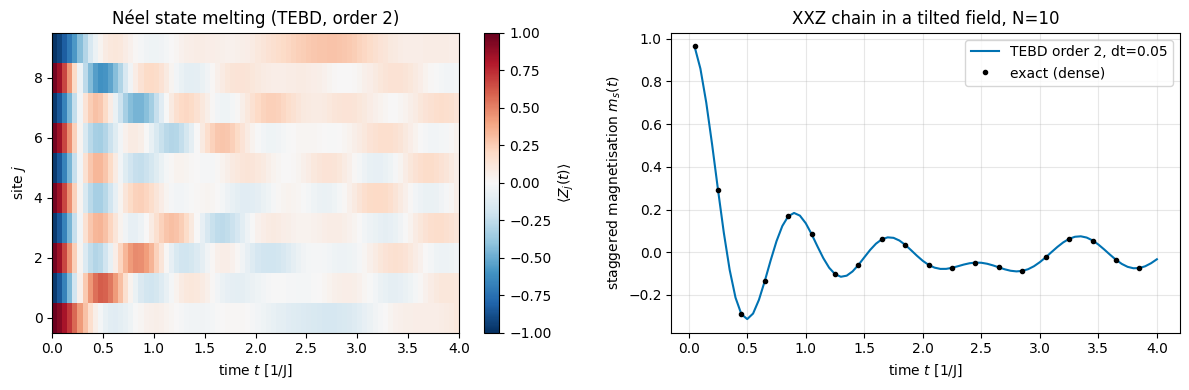

In [10]:
# ==============================================================================
# STEP 4: observables inside the scan -- magnetisation profile and energy at every step
# ==============================================================================
def z_profile(psi):
    """All <Z_j> at once from the probabilities p(s) = |psi[s]|^2.

    MATH   <Z_j> = sum_s p(s) (1 - 2 s_j) = P(s_j = 0) - P(s_j = 1);   P(s_j) = p summed over all axes except j.
    COST   O(N 2^N), no complex arithmetic.
    """
    p = jnp.abs(psi) ** 2
    n = psi.ndim
    marg = [jnp.sum(p, axis=tuple(a for a in range(n) if a != j)) for j in range(n)]       # N arrays of shape (2,)
    return jnp.stack([m[0] - m[1] for m in marg])


def staggered_magnetisation(z):
    """m_s = (1/N) sum_j (-1)^j <Z_j>   (works on a profile of shape (..., N))."""
    n = z.shape[-1]
    return jnp.sum(z * (-1.0) ** jnp.arange(n), axis=-1) / n


# ------------------------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------------------------
T_obs, dt_obs = 4.0, 0.05
n_obs = int(round(T_obs / dt_obs))
observe = lambda p: (z_profile(p), energy(terms_eo, p))

run_scan = jax.jit(lambda p: tebd_evolve(p, terms_eo, dt_obs, n_obs, order=2, observe=observe))
psi_end, (z_t, E_t) = run_scan(psi0)
times = dt_obs * np.arange(1, n_obs + 1)

# exact reference for the observable (dense, N=10): one eigendecomposition, all times
ms_exact = np.array([float(staggered_magnetisation(z_profile(exact(psi0, t)))) for t in times[::4]])
ms_tebd = np.asarray(staggered_magnetisation(z_t))
err_obs = np.max(np.abs(ms_tebd[::4] - ms_exact))
print(f"max |m_s(TEBD) - m_s(exact)| over 0 < t <= {T_obs}: {err_obs:.2e}   (order 2, dt = {dt_obs})")
assert err_obs < 1e-2

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
im = axL.imshow(np.asarray(z_t).T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1, extent=[0, T_obs, -0.5, N - 0.5])
plt.colorbar(im, ax=axL, label=r"$\langle Z_j(t)\rangle$"); axL.grid(False)
axL.set_xlabel("time $t$ [1/J]"); axL.set_ylabel("site $j$"); axL.set_title("Néel state melting (TEBD, order 2)")
axR.plot(times, ms_tebd, label=f"TEBD order 2, dt={dt_obs}")
axR.plot(times[::4], ms_exact, "o", ms=3, color=CB[6], label="exact (dense)")
axR.set_xlabel("time $t$ [1/J]"); axR.set_ylabel(r"staggered magnetisation $m_s(t)$"); axR.set_title(f"XXZ chain in a tilted field, N={N}"); axR.legend()
plt.tight_layout(); plt.show()

The checkerboard pattern of the Néel state fades within a time of order $1/J$: the hopping term $XX+YY$ exchanges neighbouring antiparallel spins, and the staggered magnetisation relaxes to small values with damped oscillations. TEBD (line) follows the exact result
(dots) with an error at the $10^{-3}$ level or below at this step size. The physics of such quenches is the subject of [notebook 15 (Chapter 5)](15_quench_dynamics_spin_chains.ipynb); here we care about the *error*.

## 7. Measured error scaling

### 7.1 Local and global error versus $dt$

We measure the state error $\epsilon=\big\||\psi_{\rm TEBD}\rangle-|\psi_{\rm exact}\rangle\big\|$ in two settings:

* **local error**: one step of size $dt$, compared with $e^{-iH\,dt}|\psi_0\rangle$ — expected $\propto dt^{p+1}$;
* **global error**: evolve to a fixed time $T=2$ with $n=T/dt$ steps — expected $\propto dt^{p}$, Eq. (4).

For the second-order scheme we also include the "sweep" ordering (engine term list: bonds left to right, then fields) to see how much the ordering matters.

> **Numerical practice.** On a log–log plot a power law $\epsilon=C\,dt^p$ is a straight line of slope $p$. *Always draw reference slopes and always fit the measured slope*: a formula that is "fourth order on paper" but shows slope 2 in the plot has a bug
> (a typical one: a wrong coefficient in one sub-step).

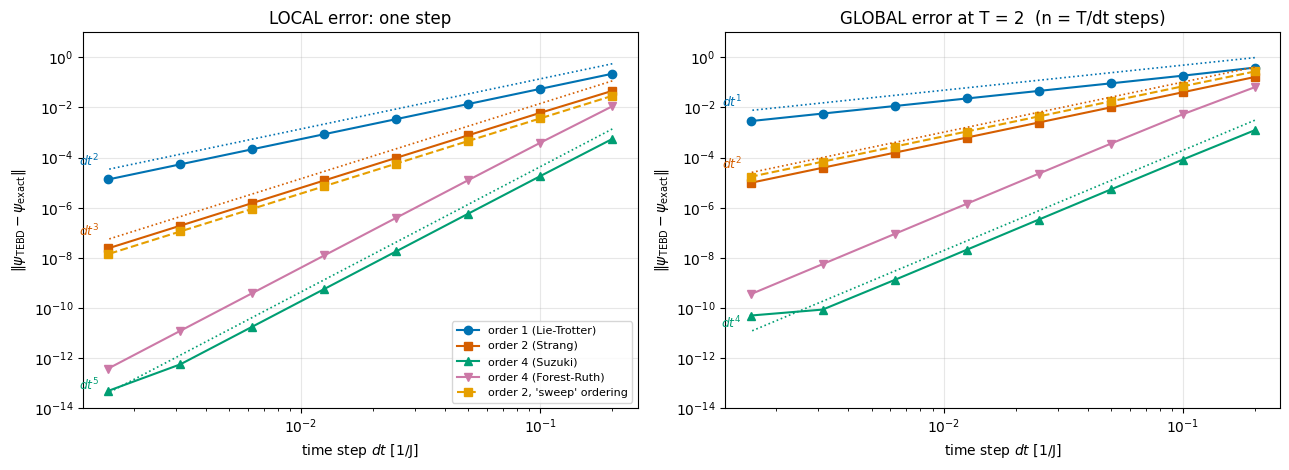

scheme                        local slope (expected)    global slope (expected)    global error at dt=0.05
  order 1 (Lie-Trotter)          2.00  (2)                1.00  (1)                  9.18e-02
  order 2 (Strang)               2.99  (3)                2.00  (2)                  1.01e-02
  order 4 (Suzuki)               4.97  (5)                3.98  (4)                  5.33e-06
  order 4 (Forest-Ruth)          4.95  (5)                3.93  (4)                  3.59e-04
  order 2, 'sweep' ordering      3.00  (3)                2.00  (2)                  1.76e-02


In [11]:
# ==============================================================================
# EXPERIMENT 1: local and global error vs dt for all schemes  (N=10, Neel state, T=2)
# ==============================================================================
T_glob = 2.0
n_list = np.array([10, 20, 40, 80, 160, 320, 640, 1280])
dt_list = T_glob / n_list
psi_T_exact = exact(psi0, T_glob)

propagators["2sweep"] = make_propagator(terms_sweep, "2")
GATE_BUILDERS["2sweep"] = GATE_BUILDERS["2"]; ORDER_OF["2sweep"] = 2; LABEL["2sweep"] = "order 2, 'sweep' ordering"
# (the 'sweep' list describes the SAME Hamiltonian -- Checkpoint in Section 4.4 -- so the same exact reference applies)

err_local, err_global = {}, {}
for scheme, prop in propagators.items():
    err_local[scheme] = np.array([float(jnp.linalg.norm(prop(psi0, dt, 1) - exact(psi0, dt))) for dt in dt_list])
    err_global[scheme] = np.array([float(jnp.linalg.norm(prop(psi0, dt, int(n)) - psi_T_exact)) for dt, n in zip(dt_list, n_list)])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
styles = {"1": ("o-", CB[0]), "2": ("s-", CB[1]), "2sweep": ("s--", CB[4]), "4": ("^-", CB[2]), "4FR": ("v-", CB[3])}
for scheme in propagators:
    mk, c = styles[scheme]
    axL.loglog(dt_list, err_local[scheme], mk, color=c, label=LABEL[scheme])
    axR.loglog(dt_list, err_global[scheme], mk, color=c, label=LABEL[scheme])
for p, c in ((1, CB[0]), (2, CB[1]), (4, CB[2])):                       # reference slopes, anchored at the largest dt
    axL.loglog(dt_list, err_local[str(p)][0] * (dt_list / dt_list[0]) ** (p + 1) * 2.5, ":", color=c, lw=1.2)
    axR.loglog(dt_list, err_global[str(p)][0] * (dt_list / dt_list[0]) ** p * 2.5, ":", color=c, lw=1.2)
    axL.text(dt_list[-1] * 0.92, err_local[str(p)][0] * (dt_list[-1] / dt_list[0]) ** (p + 1) * 2.5, f"$dt^{p + 1}$", color=c, ha="right", va="bottom", fontsize=9)
    axR.text(dt_list[-1] * 0.92, err_global[str(p)][0] * (dt_list[-1] / dt_list[0]) ** p * 2.5, f"$dt^{p}$", color=c, ha="right", va="bottom", fontsize=9)
axL.set_title("LOCAL error: one step"); axR.set_title(f"GLOBAL error at T = {T_glob:g}  (n = T/dt steps)")
for ax in (axL, axR):
    ax.set_xlabel("time step $dt$ [1/J]"); ax.set_ylabel(r"$\|\psi_{\rm TEBD}-\psi_{\rm exact}\|$"); ax.set_ylim(1e-14, 10)
axL.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()


def fitted_slope(dts, errs, floor=1e-9):
    """Slope of log(err) vs log(dt), using only points above the round-off floor and below saturation.

    The floor matters: with thousands of steps the accumulated round-off reaches ~1e-10 (see the flattening of the
    fourth-order curve in the figure), and including those points would bias the fitted slope downwards.
    """
    keep = (errs > floor) & (errs < 0.3)
    return np.polyfit(np.log(dts[keep]), np.log(errs[keep]), 1)[0]


print("scheme                        local slope (expected)    global slope (expected)    global error at dt=0.05")
for scheme in propagators:
    p = ORDER_OF[scheme]
    print(f"  {LABEL[scheme]:27s}   {fitted_slope(dt_list, err_local[scheme]):5.2f}  ({p + 1})               {fitted_slope(dt_list, err_global[scheme]):5.2f}  ({p})"
          f"                  {err_global[scheme][2]:.2e}")
    assert abs(fitted_slope(dt_list, err_global[scheme]) - p) < 0.35

**Reading the plots.**

* The fitted slopes reproduce the theory: $p+1$ for one step, $p$ at fixed final time, for $p=1,2,4$ — the dotted lines are pure power laws for comparison.
* At the *same* $dt$ the fourth-order errors are many orders of magnitude smaller: at $dt=0.05$ Suzuki's formula is already at the $10^{-6}$ level where Strang has $10^{-2}$ and Lie–Trotter $10^{-1}$. For the smallest steps the fourth-order curve
  approaches the **round-off floor** and visibly flattens: the 1280 steps at the smallest $dt$ apply $\sim10^5$ double-precision gates and accumulate errors of order $10^{-10}$ (consistent with the norm drift of $4\times10^{-12}$
  printed in Checkpoint 4 after 100 steps). Points below that floor are excluded from the slope fit, which is why the printed fourth-order slopes come out at their theoretical values. Below the floor, decreasing $dt$ is not only useless but harmful —
  more gates, more round-off. *High-order methods have an optimal $dt$.*
* Forest–Ruth is fourth order, but with an error constant almost two orders of magnitude worse than Suzuki's formula: at $dt=0.05$ the two global errors differ by a factor $3.59\times10^{-4}/5.33\times10^{-6}=67$, close to the ratio $71$ of the coefficients $\sum_ic_i^5$ printed in
  Section 5.2 — the price of sub-steps of length $1.35\,dt$ and $-1.70\,dt$.
* The ordering of the terms changes the prefactor (here by less than a factor of two) and leaves the slope unchanged: the two second-order curves of the global error are parallel.

### 7.2 Error accumulation in time

Equation (4) bounds the growth of the error by a straight line, $\epsilon(t)\le(t/dt)\,\epsilon_{\rm local}$. To see how tight the bound is, we fix $dt$ and record the error after every step. (We use the scan to collect all intermediate *states* — affordable at $N=10$ — and compare them with the exact states.)

order 1 (Lie-Trotter)    error at t=1: 1.01e-01,  t=10: 1.11e-01,  t=20: 1.32e-01   ratio err(20)/err(10) = 1.19


order 2 (Strang)         error at t=1: 5.67e-03,  t=10: 5.00e-02,  t=20: 9.95e-02   ratio err(20)/err(10) = 1.99


order 4 (Suzuki)         error at t=1: 3.30e-06,  t=10: 2.47e-05,  t=20: 4.92e-05   ratio err(20)/err(10) = 1.99


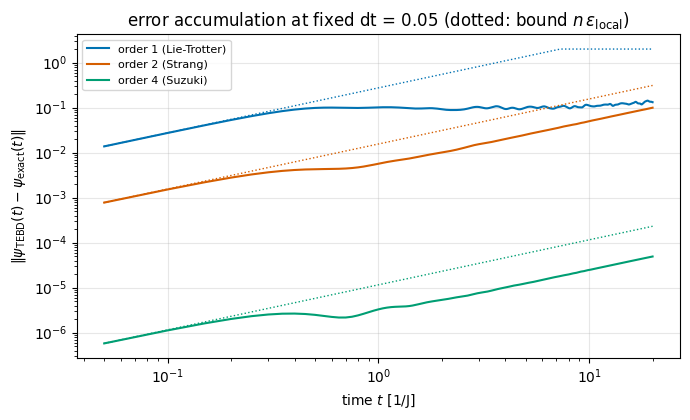

In [12]:
# ==============================================================================
# EXPERIMENT 2: growth of the state error with time at fixed dt
# ==============================================================================
T_long, dt_acc = 20.0, 0.05
n_acc = int(round(T_long / dt_acc))
t_acc = dt_acc * np.arange(1, n_acc + 1)
# exact states at all times from ONE eigendecomposition:  psi(t_k) = V exp(-i w t_k) V^dag psi0
w_ex, V_ex = jnp.linalg.eigh(dense_hamiltonian(terms_eo, N))
c0 = V_ex.conj().T @ psi0.reshape(-1)
exact_states = (jnp.exp(-1j * jnp.asarray(t_acc)[:, None] * w_ex[None, :]) * c0[None, :]) @ V_ex.T        # (n_steps, 2^N)

fig, ax = plt.subplots(figsize=(7, 4.3))
for scheme, order in (("1", 1), ("2", 2), ("4", 4)):
    _, states = jax.jit(lambda p: tebd_evolve(p, terms_eo, dt_acc, n_acc, order=order, observe=lambda q: q.reshape(-1)))(psi0)
    err_t = np.asarray(jnp.linalg.norm(states - exact_states, axis=1))
    mk, c = styles[scheme]
    ax.loglog(t_acc, err_t, "-", color=c, label=LABEL[scheme])
    ax.loglog(t_acc, np.minimum(err_t[0] * t_acc / dt_acc, 2.0), ":", color=c, lw=1)          # bound (4): n * local error
    print(f"{LABEL[scheme]:24s} error at t=1: {err_t[int(1 / dt_acc) - 1]:.2e},  t=10: {err_t[int(10 / dt_acc) - 1]:.2e},  t=20: {err_t[-1]:.2e}"
          f"   ratio err(20)/err(10) = {err_t[-1] / err_t[int(10 / dt_acc) - 1]:.2f}")
ax.set_xlabel("time $t$ [1/J]"); ax.set_ylabel(r"$\|\psi_{\rm TEBD}(t)-\psi_{\rm exact}(t)\|$")
ax.set_title(f"error accumulation at fixed dt = {dt_acc} (dotted: bound $n\\,\\epsilon_{{\\rm local}}$)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

* For orders 2 and 4 the error grows **linearly in time** at late times (the printed ratio $\epsilon(20)/\epsilon(10)\approx2$) and stays below the telescoping bound $n\,\epsilon_{\rm local}$ (dotted). The bound is not tight: consecutive local errors
  partially cancel instead of adding up coherently.
* The **first-order** curve looks different: it rises to $\approx0.1$ within a time of order $1/J$ and then hardly grows. The reason is a change of frame, derived right below the list.

Take the first-order step in the ordering the code uses, $S_1(dt)=e^{-iB\,dt}e^{-iA\,dt}$ with $A$ = even bonds, and move half of the last-applied layer to the other end by inserting $\mathbb 1=e^{+iA\,dt/2}e^{-iA\,dt/2}$ on the left:

$$ S_1(dt)=e^{+iA\,dt/2}\,\underbrace{\big[e^{-iA\,dt/2}e^{-iB\,dt}e^{-iA\,dt/2}\big]}_{S_2(dt)}\,e^{-iA\,dt/2}\quad\Longrightarrow\quad S_1(dt)^n=e^{+iA\,dt/2}\,S_2(dt)^n\,e^{-iA\,dt/2}, $$

because in $S_1^n$ all the inner factors $e^{-iA\,dt/2}e^{+iA\,dt/2}$ cancel. The $S_2$ appearing here is exactly the second-order scheme plotted alongside. So the Lie–Trotter evolution *is* the Strang evolution, viewed in a frame rotated by the fixed small unitary $e^{-iA\,dt/2}$.
Its error consists of a **non-accumulating** $O(dt)$ part — the frame rotation, present already after the first step and never growing, which is the plateau — plus the slowly accumulating $O(t\,dt^2)$ error of $S_2$: by $t=20$ the second-order error has almost caught up with it.
This is one more way to see that second order costs nothing extra: it is first order with the two half-layers at the ends put in the right place.

The practical consequence of linear accumulation: to keep a fixed accuracy up to time $t$ with a method of order $p$ one needs $dt\propto t^{-1/p}$, i.e. a number of steps $n\propto t^{1+1/p}$ — another argument for higher orders in long simulations.

> **Common pitfall.** A state error of $10^{-2}$ does *not* mean that every observable is wrong by $10^{-2}$. Local observables are typically much more accurate than the full many-body state (their error is governed by local commutators, and many error components are
> orthogonal to what the observable measures), whereas the fidelity $|\langle\psi_{\rm exact}|\psi\rangle|^2\approx1-\epsilon^2$ looks deceptively good. Decide which quantity you need and test the convergence of *that* quantity.

### 7.3 How the error grows with the system size

Everything so far was measured at $N=10$. A simulator is used at $N=30$ or $N=100$, so the third variable — after $dt$ and $t$ — is the size of the system. The sharpest general statement available is the **commutator bound** of Childs, Su, Tran, Wiebe and Zhu (2021): for a
$p$-th order product formula built from $H=\sum_\gamma h_\gamma$,

$$ \big\|S_p(dt)-e^{-iH\,dt}\big\|\;=\;O\big(\alpha_{\rm comm}\,dt^{\,p+1}\big),\qquad \alpha_{\rm comm}=\sum_{\gamma_1,\dots,\gamma_{p+1}}\big\|\big[h_{\gamma_{p+1}},\dots,\big[h_{\gamma_2},h_{\gamma_1}\big]\big]\big\| , $$

the sum running over all $(p+1)$-tuples of terms, and the constant hidden in $O(\cdot)$ depending only on the formula. Only *nested commutators* appear — the bound is zero when the terms commute, which no bound written in terms of $\|H\|$ alone can achieve. Two consequences for a chain of $N$ spins with
nearest-neighbour bonds of bounded strength:

* A nested commutator vanishes unless the terms involved overlap on the lattice, so only $O(N)$ of the terms in $\alpha_{\rm comm}$ survive: $\alpha_{\rm comm}=O(N)$. The error of one step is **extensive**, and the global state error is $O(N\,t\,dt^{\,p})$. To hold the error of the
  *state* fixed while the chain grows, $dt$ must shrink like $(\varepsilon/Nt)^{1/p}$, so the total number of gates behaves as $N\,t/dt=O\big((Nt)^{1+1/p}\varepsilon^{-1/p}\big)$.
* For a **local observable** the situation is much better: the error of $\langle Z_j\rangle$ is controlled by commutators in a finite neighbourhood of site $j$ and does not grow with $N$ at all (Childs *et al.* 2021, section "Applications to simulating local observables"; Heyl, Hauke and Zoller 2019).

The extensive bound is a worst case over all states. On a given state the error contributions of different bonds are vectors that need not add coherently, and for a product state they are nearly orthogonal, so their norms add in quadrature. The cell below measures both effects:
the prefactor $\|[B,A]\psi_0\|$ of Eq. (3') up to $N=18$ (matrix-free, no exact reference needed), and — where a dense reference is affordable — the state error against the error of the single local observable $\langle Z_{N/2}\rangle$.

In [13]:
# ==============================================================================
# EXPERIMENT 2b: system-size dependence of the Trotter error (Neel state, order 2, dt = 0.05, T = 1)
# ==============================================================================
dt_N, T_N = 0.05, 1.0
print("   N   ||[B,A]psi0||   ||[B,A]psi0||^2   state error at T=1    |d<Z_(N/2)>|")
for N_s in (6, 8, 10, 12, 14, 16, 18):
    terms_s = even_odd_order(absorb_fields_into_bonds(heisenberg_terms(N_s, Jxx=J, Jyy=J, Jzz=J * Delta, hx=hx, hz=hz), N_s))
    A_s, B_s = layers(terms_s)
    psi_s = product_state("01" * (N_s // 2))
    c_s = float(jnp.linalg.norm(commutator_on_state(B_s, A_s, psi_s)))
    line = f"  {N_s:2d}     {c_s:8.4f}       {c_s**2:9.3f}"
    if N_s <= 10:                                                   # dense reference: 2^N x 2^N eigendecomposition
        psi_num = psi_s
        for _ in range(int(round(T_N / dt_N))):
            psi_num = apply_gates(psi_num, tebd_gates(terms_s, dt_N, order=2))
        psi_ref = exact_evolve(psi_s, terms_s, T_N)
        dz = abs(float(z_profile(psi_num)[N_s // 2] - z_profile(psi_ref)[N_s // 2]))
        line += f"        {float(jnp.linalg.norm(psi_num - psi_ref)):.3e}            {dz:.3e}"
    print(line)

   N   ||[B,A]psi0||   ||[B,A]psi0||^2   state error at T=1    |d<Z_(N/2)>|


   6       7.5286          56.680        3.498e-03            1.009e-03


   8       9.4170          88.680        4.624e-03            1.164e-03


  10      10.9854         120.680        5.670e-03            7.734e-04


  12      12.3564         152.680


  14      13.5897         184.680


  16      14.7201         216.680


  18      15.7696         248.680


The commutator prefactor grows **sub-linearly**. Its square grows by exactly $32$ for every two added sites, $\|[B,A]\psi_0\|^2=16N-39.3$, so the prefactor approaches $4\sqrt N$ rather than the linear growth of the worst-case bound. On this real product state, commutators of
non-overlapping groups of bonds give orthogonal vectors (each has zero expectation value, since $[B,A]$ is a real antisymmetric matrix), and only the $O(N)$ overlapping pairs contribute to the squared norm: the bond contributions add in quadrature. The state error at fixed $dt$ grows with $N$ all the same — there is no size at which a fixed $dt$ is "good enough" for the full many-body state — whereas the error of the local observable $\langle Z_{N/2}\rangle$ stays at
$10^{-3}$ over the sizes we can check against a dense reference. This is the quantitative version of the *Common pitfall* box above: a simulation that reports local observables can use a larger step than a fidelity-based error budget would allow.

## 8. Conserved quantities as diagnostics

On a large system there is no exact reference, and the conserved quantities of the *exact* dynamics become the diagnostics. We classify them by what the *Trotterised* dynamics does to them.

**(a) The norm** — conserved *exactly* by every product formula, for any $dt$, because each gate is unitary. A drifting norm signals a bug or accumulating round-off in very long runs. But a perfectly conserved norm says **nothing** about accuracy:
the evolution with $dt=1$ below is unitary to round-off and far from the exact state.

**(b) Symmetries shared by every gate** — if $[h_k,Q]=0$ for all terms, then each gate commutes with $Q$ and $\langle Q\rangle$ (in fact the full distribution of $Q$) is conserved *exactly* by the Trotterised dynamics. Example: the magnetisation
$M=\sum_jZ_j$ of the XXZ chain ($h_x=0$). Like the norm, it tests the *implementation* and is insensitive to $dt$; a wrong gate, a wrong index convention or a field term pointing in the wrong direction shows up immediately.

**(c) The energy** — conserved by the exact dynamics, but **not** by the product formula, since $[S(dt),H]\ne0$. A generator always exists: $S(dt)$ is unitary, so $S(dt)=e^{-i\,dt\,H_{\rm eff}}$ with a Hermitian $H_{\rm eff}=i\log S(dt)/dt$, unambiguous as long as $dt$ is small enough for the
logarithm to be single-valued. Eqs. (5)–(6) are the first terms of its expansion, $H_{\rm eff}=H+O(dt^p)$; this *effective* (or "shadow") Hamiltonian is conserved exactly by the stroboscopic evolution, since $[S(dt),H_{\rm eff}]=0$. Hence

$$ \langle H\rangle_t-\langle H\rangle_0=-\big(\langle H_{\rm eff}-H\rangle_t-\langle H_{\rm eff}-H\rangle_0\big)=O(dt^p)\quad\text{at all measured times }t=n\,dt: $$

the energy error **oscillates but does not drift**, with an amplitude $\propto dt^p$. This makes $\max_t|\langle H\rangle_t-\langle H\rangle_0|$ a cheap, reference-free indicator of whether $dt$ is small enough. (The same mechanism explains the excellent long-time energy behaviour of
symplectic integrators in classical mechanics — leapfrog/Verlet is the Strang splitting of $H=T+V$; Hairer, Lubich and Wanner (2006), Chapter IX, develop this backward error analysis.)

Two caveats belong with this argument. First, $H_{\rm eff}$ is a *local* operator only as long as the expansion behaves: the series of nested commutators is asymptotic, not convergent, and for a many-body system its truncation is useful only while $dt$ times the local energy
scale is small. Second, "does not drift" is a statement about a long but finite time. Rigorous results for Floquet systems — and a Trotterised evolution is a periodically driven system, with period $dt$ — show that the energy stays close to its initial value for a time
that grows exponentially in the driving frequency $2\pi/dt$ (Mori, Kuwahara and Saito 2016; Abanin, De Roeck, Ho and Huveneers 2017). After that time a generic interacting system is expected to absorb energy from the "drive" slowly and approach a featureless state in which every local observable takes its value in the maximally mixed state. At larger $dt$ there is a threshold beyond which the Trotter error stops being perturbative altogether (Heyl, Hauke and
Zoller 2019); the numbers below stay far on the safe side of it.

initial state: <H> = 3.900000, M = 2.0


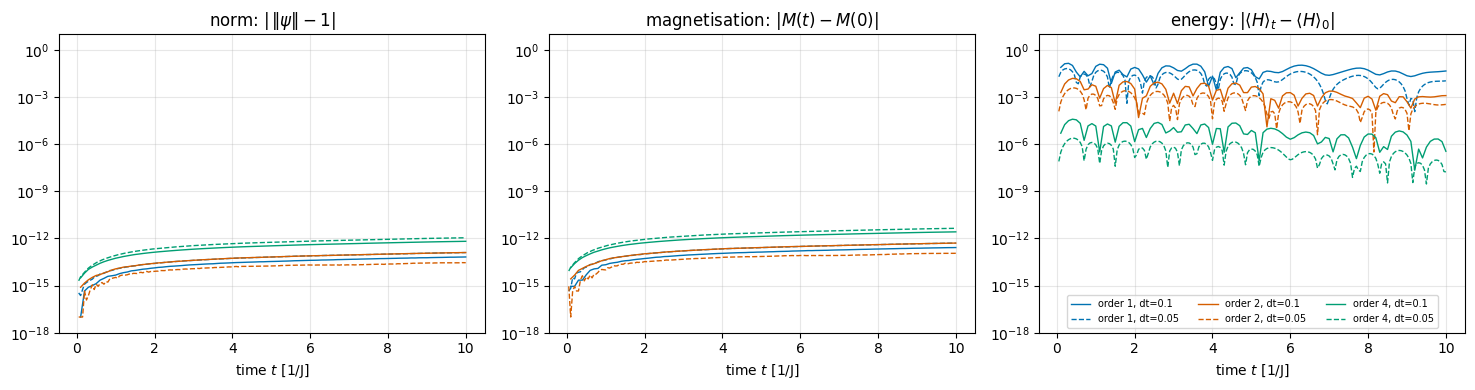

max_t |E(t) - E(0)|:
  order 1:  dt=0.1: 1.43e-01   dt=0.05: 6.64e-02   ratio =   2.15   (expected 2^1 = 2)
  order 2:  dt=0.1: 1.57e-02   dt=0.05: 3.87e-03   ratio =   4.05   (expected 2^2 = 4)
  order 4:  dt=0.1: 3.95e-05   dt=0.05: 2.43e-06   ratio =  16.24   (expected 2^4 = 16)



dt = 1.0 (order 2), T = 10:  |norm - 1| = 1.6e-14,  M = 2.000000000000,  but fidelity with the exact state = 0.008


In [14]:
# ==============================================================================
# EXPERIMENT 3: norm, magnetisation and energy along TEBD trajectories  (XXZ chain without transverse field: [H, M] = 0)
# ==============================================================================
terms_xxz = even_odd_order(absorb_fields_into_bonds(heisenberg_terms(N, Jxx=J, Jyy=J, Jzz=J * Delta, hz=hz), N))
psi_dw = product_state("0" * (N // 2 + 1) + "1" * (N // 2 - 1))          # domain wall with M = sum_j <Z_j> = +2
T_cons = 10.0


def diagnostics(p):
    """Per-step record: (norm - 1, total magnetisation M, energy)."""
    return (jnp.linalg.norm(p) - 1.0, jnp.sum(z_profile(p)), energy(terms_xxz, p))


E_init, M_init = float(energy(terms_xxz, psi_dw)), float(jnp.sum(z_profile(psi_dw)))
print(f"initial state: <H> = {E_init:.6f}, M = {M_init:.1f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
energy_dev = {}
for order, c in ((1, CB[0]), (2, CB[1]), (4, CB[2])):
    for dt_c, ls in ((0.1, "-"), (0.05, "--")):
        n_c = int(round(T_cons / dt_c))
        _, (dn, M_t, E_tt) = jax.jit(lambda p: tebd_evolve(p, terms_xxz, dt_c, n_c, order=order, observe=diagnostics))(psi_dw)
        tt = dt_c * np.arange(1, n_c + 1)
        energy_dev[(order, dt_c)] = float(jnp.max(jnp.abs(E_tt - E_init)))
        axes[0].plot(tt, np.abs(np.asarray(dn)) + 1e-17, ls, color=c, lw=1)
        axes[1].plot(tt, np.abs(np.asarray(M_t) - M_init) + 1e-17, ls, color=c, lw=1)
        axes[2].plot(tt, np.abs(np.asarray(E_tt) - E_init) + 1e-17, ls, color=c, lw=1, label=f"order {order}, dt={dt_c}")
for ax, title in zip(axes, (r"norm: $|\,\|\psi\|-1|$", r"magnetisation: $|M(t)-M(0)|$", r"energy: $|\langle H\rangle_t-\langle H\rangle_0|$")):
    ax.set_yscale("log"); ax.set_ylim(1e-18, 10); ax.set_xlabel("time $t$ [1/J]"); ax.set_title(title)
axes[2].legend(fontsize=7, ncol=3, loc="lower center")
plt.tight_layout(); plt.show()

print("max_t |E(t) - E(0)|:")
for order in (1, 2, 4):
    a, b = energy_dev[(order, 0.1)], energy_dev[(order, 0.05)]
    print(f"  order {order}:  dt=0.1: {a:.2e}   dt=0.05: {b:.2e}   ratio = {a / b:6.2f}   (expected 2^{order} = {2**order})")

# a perfectly unitary, perfectly wrong evolution: dt = 1
psi_bad = make_propagator(terms_xxz, "2")(psi_dw, 1.0, 10)
psi_good = exact_propagator(terms_xxz, N)(psi_dw, 10.0)
print(f"\ndt = 1.0 (order 2), T = 10:  |norm - 1| = {abs(float(jnp.linalg.norm(psi_bad)) - 1):.1e},  M = {float(jnp.sum(z_profile(psi_bad))):.12f},"
      f"  but fidelity with the exact state = {float(jnp.abs(jnp.vdot(psi_good, psi_bad))**2):.3f}")

* **Norm and magnetisation** (left, middle) sit at the round-off level $10^{-15}$–$10^{-12}$ for *every* order and *every* $dt$, slowly creeping upwards as round-off accumulates (the more gates, the faster: the fourth-order curves are the highest). They confirm that the gates are unitary and respect the $U(1)$ symmetry — nothing more.
  The last printed line shows the limitation: with $dt=1$ norm and magnetisation are conserved to round-off while the fidelity with the exact state is $0.008$.
* **Energy** (right): the deviation is bounded — it fluctuates without secular growth — and its amplitude scales as $dt^p$: the printed ratios between $dt=0.1$ and $0.05$ are close to $2$, $4$, $16$. The energy is the diagnostic that actually *sees* the Trotter error.

> **Numerical practice.** Monitor the energy (cheap: one `apply_hamiltonian` per measurement) in every production run. If $\max_t|\Delta E|$ is not small compared with the energy scales you care about (e.g. $J$ per site times the accuracy you want), reduce $dt$ or raise the order.

## 9. Special cases with zero Trotter error

Trotter error comes from commutators. When they vanish, a product formula of *any* order with *any* $dt$ is exact:

* **All terms commute.** The classical Ising chain $H=J\sum_jZ_jZ_{j+1}+h_z\sum_jZ_j$ contains only $Z$ operators. One step with $dt=T$ is the exact evolution. (The one-axis-twisting Hamiltonian $\chi\sum_{i<j}Z_iZ_j$ used for spin squeezing in quantum metrology is of this type.)
  Adding a transverse field $h_xX_j$ switches the error on, proportionally to $\|[Z_jZ_{j+1},h_xX_j]\|\propto h_x$.
* **The state is a common eigenstate of all terms.** $|\!\uparrow\uparrow\cdots\uparrow\rangle$ under the XXZ Hamiltonian: every gate only multiplies it by a phase.
* **A single bond** ($N=2$): nothing to split.

Such cases are useful as *unit tests*: any deviation from zero error is a bug.

In [15]:
# ==============================================================================
# CHECKPOINT 5: zero Trotter error for commuting Hamiltonians -- and how a transverse field switches it on
# ==============================================================================
N_c, T_c = 8, 3.0
psi_plus = product_state("+" * N_c)                                 # |+...+>: NOT an eigenstate of the Ising terms
print("classical Ising chain + transverse field hx, ONE first-order step of size dt = T = 3:")
for hx_c in (0.0, 1e-3, 1e-2, 1e-1):
    terms_c = heisenberg_terms(N_c, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=hx_c, hz=0.4)
    err = float(jnp.linalg.norm(apply_gates(psi_plus, tebd_gates(terms_c, T_c, order=1)) - exact_evolve(psi_plus, terms_c, T_c)))
    print(f"   hx = {hx_c:6.3f}:  ||psi_TEBD - psi_exact|| = {err:.2e}")
    if hx_c == 0.0:
        assert err < 1e3 * TOL

terms_h = heisenberg_terms(N_c, Jxx=1.0, Jyy=1.0, Jzz=0.7)
psi_up = product_state("0" * N_c)
err_up = float(jnp.linalg.norm(apply_gates(psi_up, tebd_gates(terms_h, T_c, order=1)) - exact_evolve(psi_up, terms_h, T_c)))
print(f"XXZ chain, fully polarised state, one step dt = 3: error = {err_up:.2e}")
assert err_up < 1e3 * TOL

classical Ising chain + transverse field hx, ONE first-order step of size dt = T = 3:


   hx =  0.000:  ||psi_TEBD - psi_exact|| = 1.42e-15
   hx =  0.001:  ||psi_TEBD - psi_exact|| = 7.44e-03
   hx =  0.010:  ||psi_TEBD - psi_exact|| = 7.41e-02
   hx =  0.100:  ||psi_TEBD - psi_exact|| = 6.82e-01


XXZ chain, fully polarised state, one step dt = 3: error = 3.62e-15


With $h_x=0$ a single gigantic step reproduces the exact state to round-off; the error then grows linearly with the strength of the non-commuting perturbation. And the fully polarised state does not notice the Trotterisation at all.

## 10. Cost: gates per step, gate fusion and the choice of the order

### 10.1 Cost model

A two-site gate costs $\approx4\cdot2^N$ complex multiply–adds and touches the whole state vector once ($16\cdot2^N$ bytes read and written). One step with $G$ gates therefore costs $O(G\,2^N)$ time and $O(2^N)$ memory — for $N\gtrsim16$ the state no longer fits into the CPU cache and the
gates are limited by memory bandwidth rather than arithmetic. The number of gates per step is the hardware-independent cost measure:

| scheme | gates per step (K bond terms) | after fusion (even/odd layers) |
|---|---|---|
| order 1 | $K$ | $K$ |
| order 2 | $2K$ | $K+K_A$ (3 layers $A\,B\,A$; across steps: $\to K$) |
| order 4 Forest–Ruth | $6K$ | 7 layers |
| order 4 Suzuki | $10K$ | 11 layers |

### 10.2 Gate fusion

Two consecutive gates on the **same pair of qubits** can be multiplied into one $4\times4$ matrix *before* touching the state: $U_2U_1$ costs 64 multiplications, applying a gate costs $4\cdot2^N$. In a gate list, a gate may also be moved past earlier gates that act on *disjoint*
qubits (they commute). The function below walks through a gate list and merges every gate into the most recent earlier gate on the same qubits whenever nothing in between blocks it. In the symmetric formulas this merges the two middle layers of $S_2$ and the touching $A$-layers of
consecutive $S_2$ factors in $S_4$. The fused list implements **the same unitary** — accuracy is unchanged, only the cost drops.

In [16]:
# ==============================================================================
# STEP 5: gate fusion -- merge gates acting on the same qubits when nothing in between blocks them
# ==============================================================================
def fuse_gates(gates):
    """Merge consecutive gates on identical qubit tuples (commuting past gates on disjoint qubits).

    MATH   ... U1(q) ... V(q') ... U2(q) ...  with q' disjoint from q   ==   ... (U2 U1)(q) ... V(q') ...
    ALGORITHM  for each new gate walk backwards through the output list: skip gates on disjoint qubits, merge into a gate on
               the SAME qubits, stop at the first gate that overlaps otherwise.   Pure list manipulation: static under jit.
    """
    out = []
    for q, U in gates:
        k = len(out) - 1
        while k >= 0:
            q_prev = out[k][0]
            if tuple(q_prev) == tuple(q):
                out[k] = (q_prev, U @ out[k][1])                 # later gate multiplies from the LEFT
                break
            if set(q_prev) & set(q):                              # overlapping but different qubits: blocked
                k = -1
                break
            k -= 1
        if k < 0:
            out.append((q, U))
    return out


print("gates per step for the even/odd list (K = 9 bonds):")
psi_r = haar_state(jax.random.PRNGKey(5), N)
for scheme in ("1", "2", "4FR", "4"):
    g_raw = GATE_BUILDERS[scheme](terms_eo, 0.1)
    g_fused = fuse_gates(g_raw)
    diff = float(jnp.linalg.norm(apply_gates(psi_r, g_raw) - apply_gates(psi_r, g_fused)))
    print(f"  {LABEL[scheme]:24s}: {len(g_raw):3d} -> {len(g_fused):3d} gates     ||psi_raw - psi_fused|| = {diff:.1e}")
    assert diff < TOL
g2 = GATE_BUILDERS["2"](terms_sweep, 0.1)
print(f"  order 2, 'sweep' list with separate field gates: {len(g2)} -> {len(fuse_gates(g2))} gates")

gates per step for the even/odd list (K = 9 bonds):


  order 1 (Lie-Trotter)   :   9 ->   9 gates     ||psi_raw - psi_fused|| = 0.0e+00
  order 2 (Strang)        :  18 ->  14 gates     ||psi_raw - psi_fused|| = 3.6e-16
  order 4 (Forest-Ruth)   :  54 ->  32 gates     ||psi_raw - psi_fused|| = 8.5e-16
  order 4 (Suzuki)        :  90 ->  50 gates     ||psi_raw - psi_fused|| = 1.3e-15
  order 2, 'sweep' list with separate field gates: 38 -> 28 gates


Fusion reduces the second-order step from 18 to 14 gates (the two middle $B$ half-layers merge: three layers $A/2,\ B,\ A/2$ with $5+4+5$ gates), Forest–Ruth from 54 to 32 (7 layers) and Suzuki's fourth-order step from 90 to 50 (11 layers), with results identical to round-off. Absorbing the
fields into the bonds was the bigger saving compared with the naive list (compare the last line).

> **JAX practice.** `fuse_gates` runs in Python on tiny matrices *before* compilation (or at trace time if `dt` is traced — the matrix products are then part of the compiled program, still negligible). XLA does not perform this algebraic simplification for us:
> it fuses element-wise operations and leaves consecutive tensor contractions as they are, so the merging has to come from the structure of the circuit.

### 10.3 Measured time per step

Now real timings of one step as a function of $N$: a jitted fused second-order step, compared with the same gate list applied un-jitted (every einsum dispatched separately from Python), and the measured scaling with the number of gates for the other schemes.

   N    gates/step   compile [s]   jit step [ms]   no-jit step [ms]   jit: ns per gate per amplitude


   8       11           0.12            0.067            3.838               23.71


  10       14           0.13            0.185            5.724               12.87


  12       17           0.16            0.795            7.820               11.42


  14       20           0.21            2.666            6.935                8.14


  16       23           0.22            6.546           18.372                4.34


  18       26           0.30           25.797           38.270                3.78


  20       29           0.42          165.813          247.462                5.45


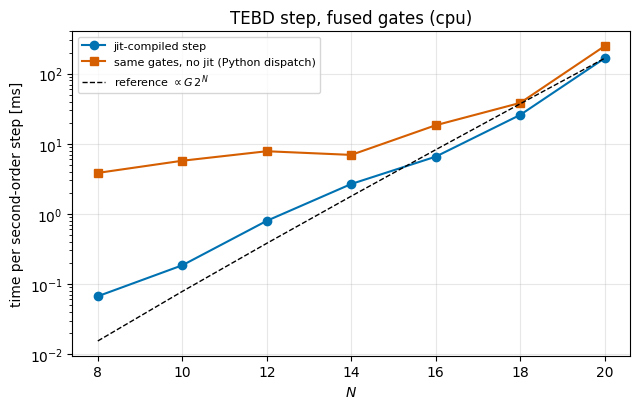

In [17]:
# ==============================================================================
# BENCHMARK 1: time per TEBD step vs N  (order 2, fused), jit vs no jit;  compile time
# ==============================================================================
def time_call(fn, arg, reps):
    """Fastest wall time of fn(arg) over `reps` calls, after one warm-up call; waits for the asynchronous result.

    WHY THE MINIMUM  the mean also measures whatever else the machine is doing (other jobs, frequency scaling, the
    garbage collector).  The fastest run is the closest estimate of the cost of the computation itself, and it is what
    one reports for a deterministic kernel.  `block_until_ready()` is essential: JAX dispatch is asynchronous, so
    without it one times the dispatch, not the arithmetic.
    """
    fn(arg).block_until_ready()                                # warm-up: compilation and buffer allocation
    best = np.inf
    for _ in range(reps):
        t0 = time.time()
        fn(arg).block_until_ready()
        best = min(best, time.time() - t0)
    return best


print("   N    gates/step   compile [s]   jit step [ms]   no-jit step [ms]   jit: ns per gate per amplitude")
bench = []
for N_b in (8, 10, 12, 14, 16, 18, 20):
    terms_b = even_odd_order(absorb_fields_into_bonds(heisenberg_terms(N_b, Jxx=J, Jyy=J, Jzz=J * Delta, hx=hx, hz=hz), N_b))
    gates_b = fuse_gates(tebd_gates(terms_b, 0.05, order=2))
    psi_b = product_state("01" * (N_b // 2))
    step_jit = jax.jit(lambda p: apply_gates(p, gates_b))
    t0 = time.time(); step_jit(psi_b).block_until_ready(); t_comp = time.time() - t0
    reps = 50 if N_b <= 14 else (10 if N_b <= 18 else 4)
    t_jit = time_call(step_jit, psi_b, reps)
    t_py = time_call(lambda p: apply_gates(p, gates_b), psi_b, max(reps // 5, 2))
    bench.append((N_b, len(gates_b), t_comp, t_jit, t_py))
    print(f"  {N_b:2d}      {len(gates_b):3d}         {t_comp:6.2f}        {t_jit * 1e3:9.3f}        {t_py * 1e3:9.3f}            {t_jit / len(gates_b) / 2**N_b * 1e9:8.2f}")

bench = np.array(bench)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(bench[:, 0], bench[:, 3] * 1e3, "o-", label="jit-compiled step")
ax.semilogy(bench[:, 0], bench[:, 4] * 1e3, "s-", label="same gates, no jit (Python dispatch)")
ax.semilogy(bench[:, 0], bench[-1, 3] * 1e3 * (bench[:, 1] / bench[-1, 1]) * 2.0 ** (bench[:, 0] - bench[-1, 0]), "k--", lw=1, label=r"reference $\propto G\,2^N$")
ax.set_xlabel("$N$"); ax.set_ylabel("time per second-order step [ms]"); ax.set_title(f"TEBD step, fused gates ({jax.default_backend()})"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

For small $N$ the jitted step is limited by fixed overheads, and compilation is what you wait for; the un-jitted version pays Python dispatch for every gate and is one to two orders of magnitude slower there. From $N\approx16$ on, both curves
bend over towards the $G\,2^N$ law (the last column, the time per gate and per amplitude, stops falling and levels off at a few nanoseconds on an idle machine, or at a few tens under heavy load): the arithmetic and the memory traffic dominate, every additional spin doubles the cost, and the advantage of `jit`
shrinks — a chain of einsums over a state that no longer fits in cache is memory-bound whoever dispatches it. The two curves can even cross at the largest size on a loaded machine, where the compiled step, which uses more threads, suffers more from the
competition. The robust results are the *scaling* with $N$ and with the number of gates; the absolute milliseconds depend on the machine and on whatever else is running on it.

### 10.4 Work–precision: choosing the order

Integrators are compared at equal accuracy: **error versus cost**. We use the number of applied two-site gates (after fusion) as the cost, which is proportional to the run time at fixed $N$, and re-use the global errors of Experiment 1 (fusion does not change them).

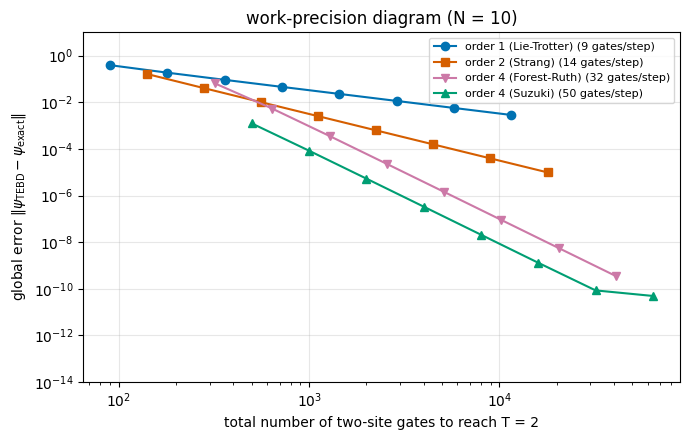

gates needed to reach a given global error at T = 2:
   target      order 1      order 2      order 4 (FR)   order 4 (Suzuki)
   1e-02          3297           562           538     <=    500
   1e-04     (> max n)          5618          1766           955
   1e-06     (> max n)     (> max n)          5603          3041
   1e-08     (> max n)     (> max n)         17724          9624


In [18]:
# ==============================================================================
# EXPERIMENT 4: work-precision diagram (global error at T=2 vs number of gates applied)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4.5))
gates_per_step = {s: len(fuse_gates(GATE_BUILDERS[s](terms_eo, 0.1))) for s in ("1", "2", "4", "4FR")}
for scheme in ("1", "2", "4FR", "4"):
    mk, c = styles[scheme]
    ax.loglog(n_list * gates_per_step[scheme], err_global[scheme], mk, color=c, label=f"{LABEL[scheme]} ({gates_per_step[scheme]} gates/step)")
ax.set_xlabel("total number of two-site gates to reach T = 2"); ax.set_ylabel(r"global error $\|\psi_{\rm TEBD}-\psi_{\rm exact}\|$")
ax.set_title(f"work-precision diagram (N = {N})"); ax.legend(fontsize=8); ax.set_ylim(1e-14, 10)
plt.tight_layout(); plt.show()


def gates_needed(scheme, target):
    """Interpolate (in log-log) the number of gates at which the global error crosses `target`."""
    x, y = np.log(n_list * gates_per_step[scheme]), np.log(err_global[scheme])
    keep = err_global[scheme] > 1e-11
    return float(np.exp(np.interp(np.log(target), y[keep][::-1], x[keep][::-1])))


print("gates needed to reach a given global error at T = 2:")
print("   target      order 1      order 2      order 4 (FR)   order 4 (Suzuki)")
for target in (1e-2, 1e-4, 1e-6, 1e-8):
    row = []
    for scheme in ("1", "2", "4FR", "4"):
        if err_global[scheme].min() > target:
            row.append("  (> max n)")                                              # not reached with the step sizes tried
        elif err_global[scheme].max() < target:
            row.append(f"  <= {n_list[0] * gates_per_step[scheme]:6d}")             # already reached with the largest dt
        else:
            row.append(f"{gates_needed(scheme, target):11.0f}")
    print(f"   {target:.0e}   " + "   ".join(row))

In this example Suzuki's fourth-order formula is the most efficient at **every** accuracy we looked at, and its advantage grows rapidly with the accuracy demanded. At the loosest target, $10^{-2}$, the three modern schemes are
essentially tied (Suzuki reaches it with the very largest step we tried, $dt=0.2$, i.e. 500 gates; Forest–Ruth and Strang need a comparable number) — with such a crude tolerance there is nothing to gain from a high order.
One digit further down the picture changes: for $10^{-4}$ Suzuki needs about six times fewer gates than second order, and errors below $10^{-6}$ are out of reach for second order with any reasonable effort. First order is not competitive at any of the four targets in the table
(remember that fused second order costs almost the same *per step*); only at tolerances so loose that a handful of steps suffices does its lower cost per step matter.
Forest–Ruth, despite fewer gates per step, loses to Suzuki because of its larger error constant. **Rule of thumb:** second order is the robust default when another error source dominates anyway
(shot noise, truncation in MPS-TEBD, a coarse time grid dictated by the observables) or when $dt\,\|h\|$ is not small (the fourth-order advantage is an asymptotic statement); fourth order for precision work and long times.

### 10.5 Unconditional stability and the choice of $dt$

Every factor of a Trotter–Suzuki step is $e^{-ih_k\tau}$ with a Hermitian $h_k$ and a real $\tau$ — of either sign. Each factor is therefore exactly unitary, and so is the whole step, **for every $dt$ and every order**: the method is unconditionally stable, and nothing in it can
blow up. The numbers confirm it: Section 8 ran the second-order scheme with $dt=1.0$, where the norm stayed at $1$ to $10^{-14}$ while the fidelity with the true state fell to $0.008$. Where an unstable method signals failure by blowing up, a Trotter step with too large a $dt$
returns a normalised, plausible and wrong state.

This is the practical difference from the explicit integrators of [notebook 04 (Chapter 2)](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb), where RK4 is stable only for $dt\,\|H\|\le2\sqrt2$ — a restriction that *tightens as the chain grows*, because
$\|H\|$ is extensive, and which has nothing to do with accuracy. For a product formula the step size is governed by accuracy alone, and the practical procedure is:

1. Decide **which quantity** must be accurate (the state, an energy, a local observable — their errors differ by orders of magnitude, Sections 7.2–7.3).
2. Start from $dt\,\|h_k\|\lesssim0.1$ for the individual terms (here $\|h_{\rm bond}\|\approx2.5J$, and $dt=0.05$ gives a state error of $10^{-2}$ at $T=2$ for second order, $5\times10^{-6}$ for Suzuki's).
3. **Verify**: halve $dt$ and compare (Section 11.1), and watch $\max_t|\Delta\langle H\rangle|$ along the run (Section 8).
4. Do not go below the round-off floor of the scheme (Section 7.1): for fourth order at $N=10$ and $T=2$ that floor ($\approx10^{-10}$) is reached at $dt$ of a few $10^{-3}$, and smaller steps only add round-off and cost.

## 11. Beyond exact references: convergence by step halving, and a free-fermion check at $N=18$

### 11.1 Estimating the error without knowing the answer

For a method of order $p$ the global error is $\epsilon(dt)\approx C\,dt^p$. Run the simulation twice, with $dt$ and $dt/2$. The two results differ by
$\delta=\|\psi_{dt}-\psi_{dt/2}\|\approx C\,dt^p\,(1-2^{-p})$, hence

$$ \epsilon(dt)\approx\frac{\delta}{1-2^{-p}},\qquad\epsilon(dt/2)\approx\frac{\delta}{2^p-1}. \qquad (7)$$

This *a-posteriori* estimate (the idea behind Richardson extrapolation and adaptive step-size control; Press *et al.* 2007, §17.3) requires no exact solution. We first validate it where we do know the answer.

In [19]:
# ==============================================================================
# CHECKPOINT 6: step-halving error estimate (7) vs true error  (N=10, T=2)
# ==============================================================================
print("scheme                     dt       true error(dt/2)    estimate from halving    ratio")
for scheme, dt_h in (("2", 0.1), ("2", 0.05), ("4", 0.2), ("4", 0.1)):
    p = ORDER_OF[scheme]
    n_h = int(round(T_glob / dt_h))
    psi_a = propagators[scheme](psi0, dt_h, n_h)
    psi_b = propagators[scheme](psi0, dt_h / 2, 2 * n_h)
    estimate = float(jnp.linalg.norm(psi_a - psi_b)) / (2 ** p - 1)
    true = float(jnp.linalg.norm(psi_b - psi_T_exact))
    print(f"  {LABEL[scheme]:24s} {dt_h:5.3f}      {true:.3e}           {estimate:.3e}            {estimate / true:.3f}")
    assert 0.5 < estimate / true < 2.0

scheme                     dt       true error(dt/2)    estimate from halving    ratio
  order 2 (Strang)         0.100      1.008e-02           1.015e-02            1.007
  order 2 (Strang)         0.050      2.517e-03           2.521e-03            1.002
  order 4 (Suzuki)         0.200      8.365e-05           7.700e-05            0.920
  order 4 (Suzuki)         0.100      5.330e-06           5.221e-06            0.980


The estimate agrees with the true error to $2\%$ or better once both step sizes are in the asymptotic regime; for the fourth-order run with $dt=0.2$, where the larger step is not yet asymptotic, it is $8\%$ low. This is the convergence test to use on large systems, ideally on the *observable of interest* rather than on the full state.

### 11.2 Domain-wall melting at $N=18$ and the free-fermion solution

We now go beyond the reach of dense references: $N=18$ spins ($2^{18}=262\,144$ amplitudes; the dense propagator would need 1.1 TB). Initial state: a **domain wall** $|\!\uparrow\cdots\uparrow\downarrow\cdots\downarrow\rangle$. Hamiltonian: the XXZ chain with $\Delta=0$ (the "XX chain") and with $\Delta=1$ (Heisenberg).

For $\Delta=0$ an exact solution exists for any $N$. The Jordan–Wigner transformation maps down-spins to fermions and $J(X_jX_{j+1}+Y_jY_{j+1})=2J(\sigma^+_j\sigma^-_{j+1}+{\rm h.c.})$ to *free* hopping with amplitude $2J$. For free particles the density evolves with the single-particle propagator
$u(t)=e^{-ih_1t}$, where $h_1$ is the $N\times N$ hopping matrix ($(h_1)_{j,j\pm1}=2J$):

$$ n_j(t)=\sum_{l\,\in\,\text{initially occupied}}|u_{jl}(t)|^2,\qquad\langle Z_j(t)\rangle=1-2\,n_j(t). $$

(Quoted without derivation; see Lieb, Schultz & Mattis 1961 for the mapping and Antal *et al.* 1999 for the domain-wall problem.) An $18\times18$ matrix exponential replaces a $262\,144$-dimensional one: an independent benchmark for the many-body code.
The front of the melting region moves with the maximal group velocity of the fermions, $v_{\max}=\max_k|\partial_k(4J\cos k)|=4J$.

Delta = 0.0: 30 steps of order 4 in 6.4 s (incl. compilation);  max|E(t)-E(0)| = 0.0e+00,  max|M(t)-M(0)| = 1.7e-14
             CHECKPOINT free fermions: max_(j,t) |<Z_j>_TEBD - <Z_j>_exact| = 1.9e-05


Delta = 1.0: 30 steps of order 4 in 5.8 s (incl. compilation);  max|E(t)-E(0)| = 1.3e-04,  max|M(t)-M(0)| = 4.7e-15


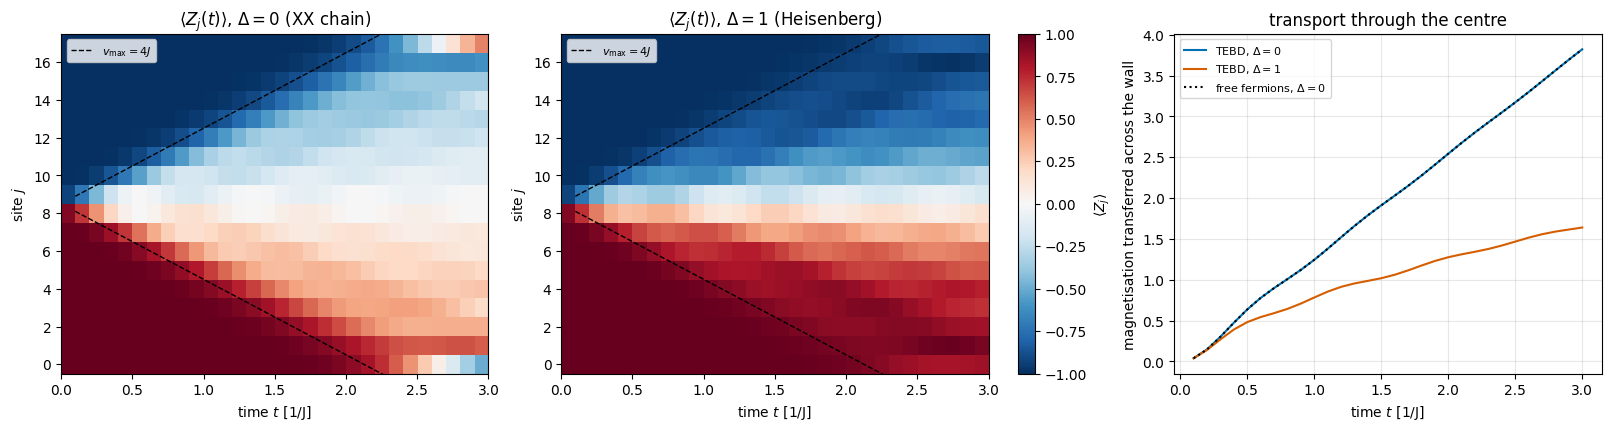

In [20]:
# ==============================================================================
# EXPERIMENT 5: domain-wall melting, N=18, Delta = 0 (free-fermion check) and Delta = 1
# ==============================================================================
def xx_chain_profile_exact(N, J, occupied, times):
    """<Z_j(t)> of the open XX chain H = J sum (XX+YY) from free fermions: n_j(t) = sum_{l occupied} |[exp(-i h1 t)]_{jl}|^2."""
    h1 = 2.0 * J * (np.diag(np.ones(N - 1), 1) + np.diag(np.ones(N - 1), -1))
    w, v = np.linalg.eigh(h1)
    out = []
    for t in times:
        u = (v * np.exp(-1j * w * t)) @ v.T
        out.append(1.0 - 2.0 * np.sum(np.abs(u[:, occupied]) ** 2, axis=1))
    return np.array(out)


# ------------------------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------------------------
N_big, T_big, dt_big, order_big = 18, 3.0, 0.1, 4
n_big = int(round(T_big / dt_big))
psi_wall = product_state("0" * (N_big // 2) + "1" * (N_big // 2))
t_big = dt_big * np.arange(1, n_big + 1)

profiles, energies, wall_clock = {}, {}, {}
for Delta_big in (0.0, 1.0):
    terms_big = even_odd_order(heisenberg_terms(N_big, Jxx=1.0, Jyy=1.0, Jzz=Delta_big))

    def run(p, dt, terms_big=terms_big):
        gates = fuse_gates(tebd_gates(terms_big, dt, order=order_big))               # dt traced, fusion at trace time
        def step(q, _):
            q = apply_gates(q, gates)
            return q, (z_profile(q), energy(terms_big, q))
        return lax.scan(step, p, None, length=n_big)

    run = jax.jit(run)
    t0 = time.time(); psi_fin, (zz, EE) = run(psi_wall, dt_big); zz.block_until_ready(); wall_clock[Delta_big] = time.time() - t0
    profiles[Delta_big], energies[Delta_big] = np.asarray(zz), np.asarray(EE)
    E_start = float(energy(terms_big, psi_wall))
    print(f"Delta = {Delta_big}: {n_big} steps of order {order_big} in {wall_clock[Delta_big]:.1f} s (incl. compilation);  "
          f"max|E(t)-E(0)| = {np.max(np.abs(energies[Delta_big] - E_start)):.1e},  max|M(t)-M(0)| = {np.max(np.abs(profiles[Delta_big].sum(axis=1))):.1e}")
    if Delta_big == 0.0:
        z_ff = xx_chain_profile_exact(N_big, 1.0, list(range(N_big // 2, N_big)), t_big)
        err_ff = np.max(np.abs(profiles[0.0] - z_ff))
        print(f"             CHECKPOINT free fermions: max_(j,t) |<Z_j>_TEBD - <Z_j>_exact| = {err_ff:.1e}")
        assert err_ff < 1e-4

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), layout="constrained")   # constrained layout keeps the colour bar clear of the 3rd panel
for ax, D in zip(axes[:2], (0.0, 1.0)):
    im = ax.imshow(profiles[D].T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1, extent=[0, T_big, -0.5, N_big - 0.5])
    ax.plot(t_big, N_big / 2 - 0.5 + 4 * t_big, "k--", lw=1); ax.plot(t_big, N_big / 2 - 0.5 - 4 * t_big, "k--", lw=1, label=r"$v_{\max}=4J$")
    ax.set_ylim(-0.5, N_big - 0.5); ax.set_xlabel("time $t$ [1/J]"); ax.set_ylabel("site $j$"); ax.grid(False)
    ax.set_title(rf"$\langle Z_j(t)\rangle$, $\Delta={D:g}$" + (" (XX chain)" if D == 0 else " (Heisenberg)")); ax.legend(loc="upper left", fontsize=8)
fig.colorbar(im, ax=axes[:2], label=r"$\langle Z_j\rangle$", fraction=0.04, pad=0.02)
for D, c in ((0.0, CB[0]), (1.0, CB[1])):
    transferred = 0.5 * np.sum(1.0 - profiles[D][:, : N_big // 2], axis=1)            # number of spins flipped in the left half
    axes[2].plot(t_big, transferred, "-", color=c, label=rf"TEBD, $\Delta={D:g}$")
axes[2].plot(t_big, 0.5 * np.sum(1.0 - z_ff[:, : N_big // 2], axis=1), "k:", label=r"free fermions, $\Delta=0$")
axes[2].set_xlabel("time $t$ [1/J]"); axes[2].set_ylabel("magnetisation transferred across the wall")
axes[2].set_title("transport through the centre"); axes[2].legend(fontsize=8)
plt.show()

* **Checkpoint:** for $\Delta=0$ the TEBD magnetisation profile of 18 spins agrees with the free-fermion solution to about $2\times10^{-5}$ at all sites and times — the size of the fourth-order Trotter error at $dt=0.1$ — an end-to-end test of gates, ordering, conventions and the scan,
  at a size where no dense reference exists. The magnetisation $M$ is conserved to round-off, as Section 8 taught us. (The energy deviation printed for $\Delta=0$ is *exactly* zero, for a reason unrelated to accuracy. $Z$ on every second site flips the sign of each $XX+YY$ bond, so combined with complex conjugation it maps every gate $e^{-ih\,dt}$ onto itself and $H$ onto $-H$;
  the domain wall is invariant under this map, hence $\langle H\rangle=0$ after every step, whatever $dt$. A diagnostic can be blind; for $\Delta=1$ the energy deviation has the expected small $O(dt^4)$ size.)
* **Physics:** in the XX chain the wall melts **ballistically**: a light-cone with the maximal velocity $v_{\max}=4J$ (dashed) opens, and the transferred magnetisation grows linearly in time until the fronts hit the ends of the chain ($t\approx N/(2v_{\max})\approx2.2$) and reflect.
  At the Heisenberg point the same light-cone limits the spreading, but the $ZZ$ interaction slows the transport of magnetisation down markedly and the curve bends. Eighteen spins up to $t=3$ cannot decide the asymptotic law. In the infinite chain the melting of the fully polarised domain wall at $\Delta=1$ is compatible with diffusive spreading with slowly decaying corrections (Misguich, Mallick and Krapivsky 2017),
  while from weakly polarised, mixed initial states spin transport at $\Delta=1$ is superdiffusive with exponent close to $2/3$ (Ljubotina, Žnidarič and Prosen 2017); the question is still under study. More physics of quenches in closed systems in Polkovnikov *et al.* (2011) and in
  [notebook 15 (Chapter 5)](15_quench_dynamics_spin_chains.ipynb).

For $\Delta=1$ there is no free-fermion solution, and the step-halving test of Section 11.1 is the only convergence measure left. We apply it to both runs: for $\Delta=0$ we can compare the *estimated* error of the magnetisation profile with the *true* one (from free fermions) —
a validation of the error estimator itself at $N=18$ — and for $\Delta=1$ the estimate is all we have.

In [21]:
# ==============================================================================
# CHECKPOINT 7: step-halving convergence test at N=18  (Delta=0: estimate vs true error;  Delta=1: estimate only)
# ==============================================================================
for Delta_big in (0.0, 1.0):
    terms_big = even_odd_order(heisenberg_terms(N_big, Jxx=1.0, Jyy=1.0, Jzz=Delta_big))

    def final_state(p, dt, n_steps, terms_big=terms_big):
        gates = fuse_gates(tebd_gates(terms_big, dt, order=order_big))
        return lax.fori_loop(0, n_steps, lambda _, q: apply_gates(q, gates), p)

    final_state = jax.jit(final_state)
    psi_dt = final_state(psi_wall, dt_big, n_big)
    psi_half = final_state(psi_wall, dt_big / 2, 2 * n_big)
    delta_psi = float(jnp.linalg.norm(psi_dt - psi_half))
    delta_z = float(jnp.max(jnp.abs(z_profile(psi_dt) - z_profile(psi_half))))
    scale = 1.0 / (1.0 - 2.0 ** (-order_big))                                   # Eq. (7): error(dt) ~ delta / (1 - 2^-p)
    print(f"Delta = {Delta_big}:  ||psi_dt - psi_dt/2|| = {delta_psi:.2e}  ->  estimated state error at dt={dt_big}: {scale * delta_psi:.2e}")
    print(f"              max_j |<Z_j>_dt - <Z_j>_dt/2| = {delta_z:.2e}  ->  estimated profile error at T: {scale * delta_z:.2e}", end="")
    if Delta_big == 0.0:
        true_z = float(np.max(np.abs(np.asarray(z_profile(psi_dt)) - z_ff[-1])))
        print(f"   |  TRUE profile error at T (free fermions): {true_z:.2e}")
        assert 0.5 < scale * delta_z / true_z < 2.0
    else:
        print(f"\n              half-chain entanglement entropy at T = {T_big}: {float(entanglement_entropy(psi_half, range(N_big // 2))):.4f} bits")

Delta = 0.0:  ||psi_dt - psi_dt/2|| = 3.07e-05  ->  estimated state error at dt=0.1: 3.27e-05
              max_j |<Z_j>_dt - <Z_j>_dt/2| = 1.41e-05  ->  estimated profile error at T: 1.51e-05   |  TRUE profile error at T (free fermions): 1.51e-05


Delta = 1.0:  ||psi_dt - psi_dt/2|| = 1.51e-04  ->  estimated state error at dt=0.1: 1.61e-04
              max_j |<Z_j>_dt - <Z_j>_dt/2| = 1.92e-05  ->  estimated profile error at T: 2.04e-05


              half-chain entanglement entropy at T = 3.0: 1.8514 bits


For the XX chain the step-halving estimate of the profile error agrees with the true error known from free fermions — the estimator works at $N=18$ just as it did at $N=10$. For the Heisenberg chain it tells us that the state is converged to about $2\times10^{-4}$ and the
magnetisation profile to about $2\times10^{-5}$ — far beyond plotting accuracy — *without any exact reference*. The entanglement entropy across the centre has grown from 0 to more than a bit: irrelevant for a state-vector simulation, but it will be the limiting
resource when we repeat such quenches with matrix product states.

## 12. Key takeaways

* For a single local term the gate $e^{-ih\,dt}$ is **exact**; Trotter error arises only from the non-commutativity of different terms, and its leading prefactor is an explicit commutator acting on the current state ($\tfrac{dt^2}{2}[A,B]$ for first order, the double commutators of Eq. (6) for second order).
* **Order $p$** means local error $O(dt^{p+1})$ and global error $O(t\,dt^p)$; errors accumulate at most linearly in time because all steps are unitary. We measured slopes $2/3/5$ (local) and $1/2/4$ (global). The error is also **extensive in $N$** in the worst case (commutator bound,
  Childs *et al.* 2021) and grows like $\sqrt N$ on the Néel state measured here, while the error of a *local* observable does not grow with $N$ at all.
* **Symmetric** products (Strang) have only odd powers of $dt$ in their exponent — second order for free. Fourth order requires composing second-order steps with $\sum c_i=1,\ \sum c_i^3=0$, which forces negative sub-steps (Suzuki: 5 stages, small error constant; Forest–Ruth: 3 stages, large constant).
  Backward sub-steps are harmless for unitary evolution, since they are unitary too. In imaginary time they amplify instead of damping, which a lattice model with bounded terms tolerates and a diffusion operator does not.
* A product formula has **no stability restriction**: it is exactly unitary for every $dt$, unlike explicit RK4 with its $dt\,\|H\|\le2\sqrt2$. The step size is set by accuracy alone, and a wrong result looks perfectly normalised.
* Even/odd (brick-wall) layers of commuting two-site gates, fields absorbed into bonds, and **gate fusion** minimise the number of einsums per step; second order then costs about as much as first order. With that, first order is hardly ever worth using.
* **Diagnostics:** norm and gate-level symmetries (magnetisation, parity) are conserved *exactly* for any $dt$ — they test the code, not the accuracy. The **energy** is conserved only up to a bounded $O(dt^p)$ oscillation (the scheme conserves a shadow Hamiltonian): monitor it. Without an exact
  reference, **halve the step** and compare, Eq. (7).
* Implementation: gate lists are data (reorder, fuse); `jit` the step, `lax.scan` the time loop with observables, trace `dt` and use `lax.fori_loop` when many step sizes are needed; separate compile time from run time. Cost per step is $O(G\,2^N)$, memory $O(2^N)$.
* High-order formulas reach the round-off floor at moderate $dt$; beyond that, smaller steps make things *worse*.

## 13. Exercises

1. **(★) Orders on a different model.** Repeat Experiment 1 for the transverse-field Ising chain ($J_{zz}=-1$, $h_x=-1$) starting from $|\!\uparrow\cdots\uparrow\rangle$. Are the slopes the same? Compute the prefactor $\|[B,A]\psi_0\|$ of Eq. (3') for the even/odd splitting *and*
   for the splitting "$A$ = all $ZZ$ bonds, $B$ = all transverse fields" (each of the two parts is internally commuting, so each layer is again exact) and predict which first-order scheme is more accurate before measuring.
2. **(★) Closed-form gates.** Derive $e^{-i\theta(XX+YY)}$ in closed form (hint: $XX+YY$ acts only on $\{|01\rangle,|10\rangle\}$, where it equals $2X$) and use $[XX+YY,ZZ]=0$ to write the XXZ bond gate without any `eigh`. Verify against `expm_hermitian`.
3. **(★★) Extend the code: second order across steps.** Write `tebd2_evolve_merged(psi, terms_A, terms_B, dt, n_steps)` implementing $e^{-iA\,dt/2}\big[e^{-iB\,dt}e^{-iA\,dt}\big]^{n-1}e^{-iB\,dt}e^{-iA\,dt/2}$ with `lax.scan`. Verify that it gives the same state as
   `tebd_evolve(..., order=2)` and measure the speed-up at $N=16$. What is the complication if you want observables at *every* step?
4. **(★★) Order six.** Apply Suzuki's construction (Suzuki 1990; reviewed by Hatano and Suzuki 2005) once more: $S_6(dt)=S_4(s_6dt)^2S_4((1-4s_6)dt)S_4(s_6dt)^2$ with $s_6=1/(4-4^{1/5})$ (why the fifth root?). Verify slope 6 before the round-off floor spoils it, add the scheme to the work–precision diagram, and decide whether it is ever worth it in double precision.
5. **(★★) Physics: shadow Hamiltonian.** For the second-order scheme, the conserved quantity is $H_{\rm eff}=H+dt^2H_2+O(dt^4)$. Using `strang_error_vector`, record $\langle H+dt^2H_2\rangle_t$ along a trajectory and show that its fluctuations are $O(dt^4)$, much smaller than those of $\langle H\rangle_t$.
6. **(★★) Physics: light cone.** Start from $|\!\uparrow\cdots\uparrow\downarrow\uparrow\cdots\uparrow\rangle$ (one flipped spin in the middle of an $N=19$ XX chain). Plot $\langle Z_j(t)\rangle$, compare with the free-fermion formula, and extract the front velocity. How does the picture change for $\Delta=1$ and $\Delta=3$? (For large $\Delta$: think about why a single flipped spin still moves freely but a *pair* of neighbouring flipped spins is nearly stuck.)
7. **(★★★) Two dimensions.** Build the bond list of a $4\times4$ square lattice, colour the bonds into four groups of mutually disjoint bonds (horizontal-even, horizontal-odd, vertical-even, vertical-odd), and run second-order TEBD for the 2D transverse-field Ising model from $|\!\uparrow\cdots\uparrow\rangle$.
   Use energy conservation and step halving to choose $dt$. Which part of the code had to change compared with the chain?
8. **(★★★) Imaginary time.** Replace $dt\to-i\,d\tau$: the gates $e^{-h\,d\tau}$ are no longer unitary, and repeated application (with renormalisation) projects onto the ground state. Implement it, compare the energy with the Lanczos result of [notebook 11 (Chapter 5)](11_hamiltonians_and_ground_states.ipynb),
   and study how the Trotter error of the *ground-state energy* scales with $d\tau$ for orders 1 and 2. Then repeat with `order=4` and examine what the negative sub-step does (Section 5.2): compute the amplification factor $e^{|1-4s|\,d\tau\,\lambda_{\max}(h)}$ of one bond gate at
   $d\tau=0.1$, and check whether the energy still decreases monotonically along the imaginary-time trajectory as it does for orders 1 and 2.

## 14. References

**Product formulas**

* H. F. Trotter, *On the product of semi-groups of operators*, Proc. Amer. Math. Soc. **10**, 545 (1959).
* G. Strang, *On the construction and comparison of difference schemes*, SIAM J. Numer. Anal. **5**, 506 (1968).
* M. Suzuki, *Generalized Trotter's formula and systematic approximants of exponential operators and inner derivations with applications to many-body problems*, Commun. Math. Phys. **51**, 183 (1976).
* M. Suzuki, *Fractal decomposition of exponential operators with applications to many-body theories and Monte Carlo simulations*, Phys. Lett. A **146**, 319 (1990) — the five-stage fourth-order formula used here.
* M. Suzuki, *General theory of fractal path integrals with applications to many-body theories and statistical physics*, J. Math. Phys. **32**, 400 (1991) — the recursion to arbitrary order and the proof that no formula of order higher than two has only positive coefficients.
* E. Forest and R. D. Ruth, *Fourth-order symplectic integration*, Physica D **43**, 105 (1990); H. Yoshida, *Construction of higher order symplectic integrators*, Phys. Lett. A **150**, 262 (1990).
* N. Hatano and M. Suzuki, *Finding exponential product formulas of higher orders*, in *Quantum Annealing and Other Optimization Methods*, eds. A. Das and B. K. Chakrabarti, Lecture Notes in Physics **679**, pp. 37–68, Springer (2005).
* R. I. McLachlan and G. R. W. Quispel, *Splitting methods*, Acta Numerica **11**, 341–434 (2002) — the survey of splitting and composition methods and their order conditions.
* A. M. Childs, Y. Su, M. C. Tran, N. Wiebe and S. Zhu, *Theory of Trotter error with commutator scaling*, Phys. Rev. X **11**, 011020 (2021).
* M. Heyl, P. Hauke and P. Zoller, *Quantum localization bounds Trotter errors in digital quantum simulation*, Sci. Adv. **5**, eaau8342 (2019) — the threshold in $dt$, and why local observables are robust.
* E. Hairer, C. Lubich and G. Wanner, *Geometric Numerical Integration: Structure-Preserving Algorithms for Ordinary Differential Equations*, 2nd ed., Springer Series in Computational Mathematics **31**, Springer (2006) — splitting methods, backward error analysis ("shadow" Hamiltonians).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes*, 3rd ed., Cambridge University Press (2007) — §17.3 (Richardson extrapolation, the basis of the step-halving estimate of Section 11.1) and §17.4 (second-order conservative equations, the
  classical-mechanics face of Strang splitting); *Numerical Recipes in Fortran 90*, 2nd ed., Cambridge University Press (1996).

**TEBD and quantum simulation**

* G. Vidal, *Efficient classical simulation of slightly entangled quantum computations*, Phys. Rev. Lett. **91**, 147902 (2003).
* G. Vidal, *Efficient simulation of one-dimensional quantum many-body systems*, Phys. Rev. Lett. **93**, 040502 (2004).
* S. Lloyd, *Universal quantum simulators*, Science **273**, 1073 (1996).
* U. Schollwöck, *The density-matrix renormalization group in the age of matrix product states*, Ann. Phys. **326**, 96 (2011) — Section 7 on time evolution with Trotter gates.

**Physics of the examples**

* E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407 (1961).
* T. Antal, Z. Rácz, A. Rákos and G. M. Schütz, *Transport in the XX chain at zero temperature: Emergence of flat magnetization profiles*, Phys. Rev. E **59**, 4912 (1999).
* A. Polkovnikov, K. Sengupta, A. Silva and M. Vengalattore, *Colloquium: Nonequilibrium dynamics of closed interacting quantum systems*, Rev. Mod. Phys. **83**, 863 (2011).
* G. Misguich, K. Mallick and P. L. Krapivsky, *Dynamics of the spin-1/2 Heisenberg chain initialized in a domain-wall state*, Phys. Rev. B **96**, 195151 (2017).
* M. Ljubotina, M. Žnidarič and T. Prosen, *Spin diffusion from an inhomogeneous quench in an integrable system*, Nat. Commun. **8**, 16117 (2017).
* T. Mori, T. Kuwahara and K. Saito, *Rigorous bound on energy absorption and generic relaxation in periodically driven quantum systems*, Phys. Rev. Lett. **116**, 120401 (2016).
* D. Abanin, W. De Roeck, W. W. Ho and F. Huveneers, *A rigorous theory of many-body prethermalization for periodically driven and closed quantum systems*, Commun. Math. Phys. **354**, 809 (2017).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/